# Part A: Simulated K=2 Gaussian HMM Benchmark

This notebook builds the Part A simulation benchmark: data are generated from a known `K = 2` Gaussian HMM with full covariance, and then the three stochastic-gradient methods are compared on that same target. Because the latent states and parameters are known, we can evaluate mixing, parameter recovery, and state recovery directly instead of inferring quality only from the application fit.



## What this notebook does

- Simulates data from a known two-state Gaussian HMM with full covariance.
- Builds simple block features from the simulated series for targeted subsampling.
- Fits a short exact MAP Gaussian HMM baseline on the simulated data.
- Runs three samplers with checkpointing:
  - `uniform`
  - `young_static`
  - `online_feature`
- Computes `R-hat`, bulk ESS, tail ESS, posterior summaries, and state-occupancy diagnostics.
- Compares each method directly to the known truth using parameter-recovery and latent-state-recovery metrics.
- Saves outputs under a dedicated simulation benchmark directory so it stays separate from the crypto runs.



In [3]:
#%pip -q install "numpy==1.26.4" "scipy==1.11.4" "pandas==2.2.3" "matplotlib==3.8.4" "arviz==0.18.0" "xarray==2024.6.0" "scikit-learn==1.5.2" "jax==0.4.28" "jaxlib==0.4.28" "optax==0.2.2"



In [4]:
import json
import shutil
import time
from pathlib import Path

import arviz as az
import jax
import jax.numpy as jnp
import jax.scipy as jsp
import matplotlib.pyplot as plt
import numpy as np
import optax
import pandas as pd
from IPython.display import display
from jax.flatten_util import ravel_pytree
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler



## Local paths and lightweight pickle-based storage

This notebook writes into its own simulation-results directory and saves tables as pickle so it stays local-Jupyter friendly.


In [6]:
PROJECT_DIR = Path.cwd().resolve()
DATA_DIR = PROJECT_DIR / 'crypto_stage1_processed'
RESULTS_DIR = DATA_DIR / 'simulated_k2_gaussian_fullcov_part_a'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def resolve_table_path(base_path) -> Path:
    base = Path(base_path)
    candidates = [base] if base.suffix in {'.parquet', '.pkl'} else [base.with_suffix('.parquet'), base.with_suffix('.pkl')]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f'No saved table found for {base}')


def read_table(base_path) -> pd.DataFrame:
    path = resolve_table_path(base_path)
    if path.suffix == '.parquet':
        return pd.read_parquet(path)
    if path.suffix == '.pkl':
        return pd.read_pickle(path)
    raise ValueError(f'Unsupported table suffix: {path.suffix}')


def write_table(df: pd.DataFrame, base_path, index: bool = False) -> Path:
    path = Path(base_path)
    if path.suffix == '':
        path = path.with_suffix('.pkl')
    if path.suffix != '.pkl':
        raise ValueError('This notebook writes pickle tables only.')
    df_to_save = df if index else df.reset_index(drop=True)
    df_to_save.to_pickle(path)
    return path



## Simulated data and aligned block features

We generate a known two-state Gaussian HMM with persistent low-volatility and high-volatility regimes. The feature table is built directly from the simulated observations so the targeted-subsampling methods still have the same style of block covariates as in the application notebook.


## Known-truth benchmark design

The two simulated dimensions play the role of a small multivariate return panel. We keep full covariance, so each regime has its own covariance matrix and one within-state covariance term, but the overall problem is still much cleaner than the real crypto application.


In [9]:
SIM_SEED = 221
rng = np.random.default_rng(SIM_SEED)

ASSETS = ['SIM_0', 'SIM_1']
RET_COLS = [f'{asset}_ret' for asset in ASSETS]
K_SIM = 2
T = 600
d = 2

TRUE_A = np.array([
    [0.97, 0.03],
    [0.06, 0.94],
], dtype=np.float32)
TRUE_PI = np.array([0.70, 0.30], dtype=np.float32)
TRUE_MU = np.array([
    [0.08, 0.05],
    [-0.32, -0.20],
], dtype=np.float32)
TRUE_SIGMA = np.array([
    [[0.18, 0.05], [0.05, 0.12]],
    [[0.72, 0.28], [0.28, 0.55]],
], dtype=np.float32)

z_true = np.zeros(T, dtype=np.int32)
z_true[0] = rng.choice(K_SIM, p=TRUE_PI)
for t in range(1, T):
    z_true[t] = rng.choice(K_SIM, p=TRUE_A[z_true[t - 1]])

R_np = np.stack([rng.multivariate_normal(TRUE_MU[z], TRUE_SIGMA[z]) for z in z_true]).astype(np.float32)
R = jnp.asarray(R_np, dtype=jnp.float32)
dates = pd.date_range('2020-01-01', periods=T, freq='D')

returns_rollstd = pd.DataFrame({'date': dates})
for j, col in enumerate(RET_COLS):
    returns_rollstd[col] = R_np[:, j]

feature_df = pd.DataFrame({'date': dates})
for asset in ASSETS:
    col = f'{asset}_ret'
    feature_df[f'{asset}_abs_ret'] = returns_rollstd[col].abs()
    feature_df[f'{asset}_sq_ret'] = returns_rollstd[col] ** 2
    feature_df[f'{asset}_rollvol_7'] = returns_rollstd[col].rolling(7, min_periods=1).std().fillna(0.0)

feature_df['market_abs_ret'] = returns_rollstd[RET_COLS].abs().mean(axis=1)
feature_df['market_sq_ret'] = (returns_rollstd[RET_COLS] ** 2).mean(axis=1)
feature_df['cross_sectional_dispersion'] = returns_rollstd[RET_COLS].std(axis=1)
feature_df = feature_df.fillna(0.0)

truth_df = pd.DataFrame({
    'date': dates,
    'true_state': z_true,
    'true_state_0_prob': (z_true == 0).astype(float),
    'true_state_1_prob': (z_true == 1).astype(float),
})

print('simulation seed:', SIM_SEED)
print('R shape:', R_np.shape)
print('true state shares:', np.bincount(z_true, minlength=K_SIM) / len(z_true))
display(pd.DataFrame({
    'state': [0, 1],
    'true_pi': TRUE_PI,
    'true_A_kk': [TRUE_A[0, 0], TRUE_A[1, 1]],
    'true_trace_Sigma': [np.trace(TRUE_SIGMA[0]), np.trace(TRUE_SIGMA[1])],
}))
display(returns_rollstd.head())
display(feature_df.head())



simulation seed: 221
R shape: (600, 2)
true state shares: [0.82 0.18]


,state,true_pi,true_A_kk,true_trace_Sigma
0,0,0.7,0.97,0.30
1,1,0.3,0.94,1.27


,date,SIM_0_ret,SIM_1_ret
0,2020-01-01,0.400539,-0.492117
1,2020-01-02,0.060768,-0.195605
2,2020-01-03,1.143388,0.282158
3,2020-01-04,1.091950,0.632119
4,2020-01-05,0.857645,0.040662


,date,SIM_0_abs_ret,SIM_0_sq_ret,SIM_0_rollvol_7,SIM_1_abs_ret,SIM_1_sq_ret,SIM_1_rollvol_7,market_abs_ret,market_sq_ret,cross_sectional_dispersion
0,2020-01-01,0.400539,0.160431,0.000000,0.492117,0.242180,0.000000,0.446328,0.201306,0.631203
1,2020-01-02,0.060768,0.003693,0.240254,0.195605,0.038261,0.209666,0.128187,0.020977,0.181283
2,2020-01-03,1.143388,1.307336,0.553675,0.282158,0.079613,0.390658,0.712773,0.693475,0.608981
3,2020-01-04,1.091950,1.192355,0.530987,0.632119,0.399574,0.498931,0.862034,0.795965,0.325150
4,2020-01-05,0.857645,0.735555,0.467112,0.040662,0.001653,0.432146,0.449153,0.368604,0.577694


## Model and sampler settings

These settings are intended to make the simulation benchmark meaningfully easier than the application notebooks while still leaving enough room for the three subsampling methods to behave differently.


In [11]:
K = 2
DIAG_FLOOR = 1e-4
SIGMA_MU = 0.25
SIGMA_TRANS = 1.0
SIGMA_CHOL = 1.0

L = 8
B = 8

MAP_STEPS = 300
MAP_LR = 3e-3
MAP_PRINT_EVERY = 25

N_CHAINS = 4
CHAIN_INIT_NOISE = 0.01
N_STEPS = 1200
BURN_IN = 300
SAVE_EVERY = 10
CHECKPOINT_EVERY = 50
TRACE_EVERY = 10
ETA0 = 7e-5
GAMMA = 0.55
T0 = 100.0
MAX_GRAD_NORM = 250.0
MAX_PARAM_ABS = 10.0

M_UNIFORM = 3
M_EMIT = 1
M_TRANS = 1
N_WARMUP_UNIFORM = 150
EXPLORE_EPS = 0.03
RIDGE = 2.0
DISCOUNT = 0.995

print({
    'simulation_seed': SIM_SEED,
    'T': T,
    'assets': ASSETS,
    'd': d,
    'K': K,
    'N_CHAINS': N_CHAINS,
    'N_STEPS': N_STEPS,
    'BURN_IN': BURN_IN,
    'SAVE_EVERY': SAVE_EVERY,
    'M_UNIFORM': M_UNIFORM,
    'M_EMIT': M_EMIT,
    'M_TRANS': M_TRANS,
})



{'simulation_seed': 221, 'T': 600, 'assets': ['SIM_0', 'SIM_1'], 'd': 2, 'K': 2, 'N_CHAINS': 4, 'N_STEPS': 1200, 'BURN_IN': 300, 'SAVE_EVERY': 10, 'M_UNIFORM': 3, 'M_EMIT': 1, 'M_TRANS': 1}


## Gaussian HMM helpers

These are the same structural ingredients as the full project notebook, but adapted to the simpler Gaussian `K = 2` model.

In [13]:
def inv_softplus(x):
    x = np.asarray(x, dtype=np.float32)
    return np.log(np.expm1(np.maximum(x, 1e-6))).astype(np.float32)


def stationary_dist(A: jnp.ndarray, n_iter: int = 200) -> jnp.ndarray:
    def body_fun(_, pi):
        pi = pi @ A
        pi = pi / jnp.sum(pi)
        return pi
    pi0 = jnp.ones((A.shape[0],), dtype=jnp.float32) / A.shape[0]
    return jax.lax.fori_loop(0, n_iter, body_fun, pi0)


def make_cholesky(chol_lower_raw: jnp.ndarray, chol_diag_raw: jnp.ndarray) -> jnp.ndarray:
    strictly_lower = jnp.tril(chol_lower_raw, k=-1)
    diag = jax.nn.softplus(chol_diag_raw) + DIAG_FLOOR
    diag_mats = jax.vmap(jnp.diag)(diag)
    return strictly_lower + diag_mats


def unpack_params(params):
    A = jax.nn.softmax(params['trans_logits'], axis=1)
    pi = stationary_dist(A)
    mu = params['mu']
    L = make_cholesky(params['chol_lower_raw'], params['chol_diag_raw'])
    Sigma = jnp.einsum('kij,klj->kil', L, L)
    return A, pi, mu, L, Sigma


def mvnormal_logpdf_one_state(y: jnp.ndarray, mu: jnp.ndarray, L: jnp.ndarray) -> jnp.ndarray:
    d = y.shape[1]
    diff = y - mu[None, :]
    z = jsp.linalg.solve_triangular(L, diff.T, lower=True).T
    maha = jnp.sum(z ** 2, axis=1)
    logdet = 2.0 * jnp.sum(jnp.log(jnp.diag(L)))
    return -0.5 * (d * jnp.log(2.0 * jnp.pi) + logdet + maha)


def emission_loglik_matrix(y: jnp.ndarray, mu: jnp.ndarray, L: jnp.ndarray) -> jnp.ndarray:
    f = lambda mu_k, L_k: mvnormal_logpdf_one_state(y, mu_k, L_k)
    statewise = jax.vmap(f, in_axes=(0, 0))(mu, L)
    return statewise.T


def forward_pass(logpi: jnp.ndarray, logA: jnp.ndarray, emission_lp: jnp.ndarray):
    log_alpha0 = logpi + emission_lp[0]

    def step(log_alpha_prev, emission_t):
        log_alpha_t = emission_t + jsp.special.logsumexp(log_alpha_prev[:, None] + logA, axis=0)
        return log_alpha_t, log_alpha_t

    _, log_alpha_rest = jax.lax.scan(step, log_alpha0, emission_lp[1:])
    log_alpha = jnp.vstack([log_alpha0[None, :], log_alpha_rest])
    loglik = jsp.special.logsumexp(log_alpha[-1])
    return loglik, log_alpha


def backward_pass(logA: jnp.ndarray, emission_lp: jnp.ndarray):
    K_local = emission_lp.shape[1]
    log_beta_T = jnp.zeros((K_local,), dtype=jnp.float32)

    def step(log_beta_next, emission_next):
        log_beta_t = jsp.special.logsumexp(logA + emission_next[None, :] + log_beta_next[None, :], axis=1)
        return log_beta_t, log_beta_t

    rev_inputs = emission_lp[1:][::-1]
    _, rev_betas = jax.lax.scan(step, log_beta_T, rev_inputs)
    log_beta = jnp.vstack([rev_betas[::-1], log_beta_T[None, :]])
    return log_beta


def smooth_states(params, y):
    A, pi, mu, L, Sigma = unpack_params(params)
    logpi = jnp.log(pi + 1e-32)
    logA = jnp.log(A + 1e-32)
    emission_lp = emission_loglik_matrix(y, mu, L)
    ll, log_alpha = forward_pass(logpi, logA, emission_lp)
    log_beta = backward_pass(logA, emission_lp)
    log_gamma = log_alpha + log_beta
    log_gamma = log_gamma - jsp.special.logsumexp(log_gamma, axis=1, keepdims=True)
    gamma = jnp.exp(log_gamma)
    return ll, gamma


def log_prior(params):
    lp = 0.0
    lp += -0.5 * jnp.sum((params['mu'] / SIGMA_MU) ** 2)
    lp += -0.5 * jnp.sum((params['trans_logits'] / SIGMA_TRANS) ** 2)
    lp += -0.5 * jnp.sum((params['chol_lower_raw'] / SIGMA_CHOL) ** 2)
    lp += -0.5 * jnp.sum((params['chol_diag_raw'] / SIGMA_CHOL) ** 2)
    return lp


def log_likelihood(params, y):
    A, pi, mu, L, Sigma = unpack_params(params)
    logpi = jnp.log(pi + 1e-32)
    logA = jnp.log(A + 1e-32)
    emission_lp = emission_loglik_matrix(y, mu, L)
    ll, _ = forward_pass(logpi, logA, emission_lp)
    return ll


def neg_log_posterior(params, y):
    return -(log_likelihood(params, y) + log_prior(params))



## Exact MAP baseline on the simulated data

We initialize from the simulated observations, run a short MAP fit, and then use that fit as the common starting point for the samplers.


In [15]:
def initialise_params_from_data(R_np: np.ndarray, K: int = 2):
    T_local, d_local = R_np.shape
    market_abs = np.abs(R_np).mean(axis=1)
    threshold = np.median(market_abs)
    labels = (market_abs > threshold).astype(int)

    mu0 = np.zeros((K, d_local), dtype=np.float32)
    L0 = np.zeros((K, d_local, d_local), dtype=np.float32)
    A0 = np.ones((K, K), dtype=np.float32)

    for k in range(K):
        idx = np.where(labels == k)[0]
        sub = R_np[idx] if len(idx) >= d_local + 2 else R_np
        mu0[k] = sub.mean(axis=0)
        cov_k = np.cov(sub.T) + 5e-3 * np.eye(d_local)
        L0[k] = np.linalg.cholesky(cov_k)

    for t in range(1, T_local):
        A0[labels[t - 1], labels[t]] += 1.0
    A0 = A0 / A0.sum(axis=1, keepdims=True)

    traces = np.array([np.trace(L0[k] @ L0[k].T) for k in range(K)])
    order = np.argsort(traces)
    mu0 = mu0[order]
    L0 = L0[order]
    A0 = A0[order][:, order]

    chol_lower_raw = np.zeros((K, d_local, d_local), dtype=np.float32)
    chol_diag_raw = np.zeros((K, d_local), dtype=np.float32)
    for k in range(K):
        chol_lower_raw[k] = np.tril(L0[k], k=-1)
        diag_vals = np.diag(L0[k]).copy()
        diag_vals = np.maximum(diag_vals - DIAG_FLOOR, 1e-6)
        chol_diag_raw[k] = inv_softplus(diag_vals)

    return {
        'trans_logits': jnp.array(np.log(A0 + 1e-6), dtype=jnp.float32),
        'mu': jnp.array(mu0, dtype=jnp.float32),
        'chol_lower_raw': jnp.array(chol_lower_raw, dtype=jnp.float32),
        'chol_diag_raw': jnp.array(chol_diag_raw, dtype=jnp.float32),
    }


params0 = initialise_params_from_data(R_np, K=K)
optimizer = optax.adam(MAP_LR)
opt_state = optimizer.init(params0)
loss_and_grad = jax.jit(jax.value_and_grad(neg_log_posterior))

params_map = params0
map_history = []
for step in range(1, MAP_STEPS + 1):
    loss_val, grads = loss_and_grad(params_map, R)
    updates, opt_state = optimizer.update(grads, opt_state, params_map)
    params_map = optax.apply_updates(params_map, updates)
    if step == 1 or step % MAP_PRINT_EVERY == 0 or step == MAP_STEPS:
        map_history.append((step, float(loss_val)))
        print(f'step {step:3d} | neg log post = {float(loss_val):.3f}')

A_map, pi_map, mu_map, L_map, Sigma_map = unpack_params(params_map)
ll_map, gamma_map = smooth_states(params_map, R)
map_ml_state = np.asarray(gamma_map).argmax(axis=1)
map_state_share = np.bincount(map_ml_state, minlength=K) / len(map_ml_state)

print('MAP stationary distribution:', np.asarray(pi_map))
print('MAP most-likely state shares:', map_state_share)
print('MAP covariance traces:', np.trace(np.asarray(Sigma_map), axis1=1, axis2=2))



step   1 | neg log post = 779.898
step  25 | neg log post = 753.794
step  50 | neg log post = 742.635
step  75 | neg log post = 736.308
step 100 | neg log post = 731.217
step 125 | neg log post = 726.722
step 150 | neg log post = 722.718
step 175 | neg log post = 719.175
step 200 | neg log post = 716.077
step 225 | neg log post = 713.445
step 250 | neg log post = 711.265
step 275 | neg log post = 709.506
step 300 | neg log post = 708.121
MAP stationary distribution: [0.74163663 0.25836334]
MAP most-likely state shares: [0.81333333 0.18666667]
MAP covariance traces: [0.2624651 1.0842546]


## Buffered blocks and Gaussian block gradients

We reuse the same block-subsampling idea from the original notebook, but with Gaussian emissions and no `nu` parameter.

In [17]:
BLOCK_TABLE_COLUMNS = ['block_id', 'centre', 'left', 'right', 'left_buf_start', 'left_buf_end', 'right_buf_start', 'right_buf_end', 'block_width']


def make_block_table(T: int, L: int, B: int) -> pd.DataFrame:
    width = 2 * L + 1
    centres = list(range(L, T - L, width))
    rows = []
    for block_id, c in enumerate(centres):
        left = c - L
        right = c + L
        left_buf_start = max(0, left - B)
        left_buf_end = left - 1
        right_buf_start = right + 1
        right_buf_end = min(T - 1, right + B)
        rows.append({
            'block_id': block_id,
            'centre': c,
            'left': left,
            'right': right,
            'left_buf_start': left_buf_start,
            'left_buf_end': left_buf_end,
            'right_buf_start': right_buf_start,
            'right_buf_end': right_buf_end,
            'block_width': width,
        })
    return pd.DataFrame(rows, columns=BLOCK_TABLE_COLUMNS)


def prepare_block_rows(blocks_df: pd.DataFrame):
    records = blocks_df[BLOCK_TABLE_COLUMNS].to_dict(orient='records')
    return [{key: int(value) for key, value in row.items()} for row in records]


def get_block_row(blocks, j: int):
    if isinstance(blocks, pd.DataFrame):
        return blocks.iloc[int(j)]
    return blocks[int(j)]


blocks_full_df = make_block_table(T=T, L=L, B=B)
blocks_full_rows = prepare_block_rows(blocks_full_df)
N_BLOCKS = len(blocks_full_rows)
UNIFORM_BLOCK_PROBS = np.full(N_BLOCKS, 1.0 / N_BLOCKS, dtype=np.float64)
UNIFORM_BLOCK_PROBS_JAX = jnp.asarray(UNIFORM_BLOCK_PROBS, dtype=jnp.float32)

print('number of blocks:', N_BLOCKS)
display(blocks_full_df.head())



number of blocks: 35


,block_id,centre,left,right,left_buf_start,left_buf_end,right_buf_start,right_buf_end,block_width
0,0,8,0,16,0,-1,17,24,17
1,1,25,17,33,9,16,34,41,17
2,2,42,34,50,26,33,51,58,17
3,3,59,51,67,43,50,68,75,17
4,4,76,68,84,60,67,85,92,17


In [18]:
def tree_add(a, b):
    return jax.tree_util.tree_map(lambda x, y: x + y, a, b)


def tree_sub(a, b):
    return jax.tree_util.tree_map(lambda x, y: x - y, a, b)


def tree_scale(a, s):
    return jax.tree_util.tree_map(lambda x: s * x, a)


def tree_zeros_like(a):
    return jax.tree_util.tree_map(jnp.zeros_like, a)


def tree_l2_norm(a):
    flat, _ = ravel_pytree(a)
    return jnp.linalg.norm(flat)


def tree_rmse(a, b):
    flat_a, _ = ravel_pytree(a)
    flat_b, _ = ravel_pytree(b)
    return jnp.sqrt(jnp.mean((flat_a - flat_b) ** 2))


def tree_clip_by_global_norm(a, max_norm: float):
    norm = float(tree_l2_norm(a))
    if max_norm is None or max_norm <= 0:
        return a, norm, 1.0
    if not np.isfinite(norm):
        return a, norm, 0.0
    scale = min(1.0, float(max_norm) / (norm + 1e-12))
    return tree_scale(a, scale), norm, scale


def tree_all_finite(a) -> bool:
    leaves = jax.tree_util.tree_leaves(a)
    return all(np.all(np.isfinite(np.asarray(leaf))) for leaf in leaves)


def clip_unconstrained_params(params, max_abs=None):
    if max_abs is None or max_abs <= 0:
        return params
    bound = float(max_abs)
    return jax.tree_util.tree_map(lambda x: jnp.clip(x, -bound, bound), params)


def params_from_transformed(A_np, mu_np, Sigma_np):
    A_np = np.asarray(A_np, dtype=np.float32)
    A_np = np.clip(A_np, 1e-6, 1.0)
    A_np = A_np / A_np.sum(axis=1, keepdims=True)
    mu_np = np.asarray(mu_np, dtype=np.float32)
    Sigma_np = np.asarray(Sigma_np, dtype=np.float32)
    eye = np.eye(Sigma_np.shape[-1], dtype=np.float32)
    L_np = np.stack([np.linalg.cholesky(Sigma_np[k] + 1e-6 * eye) for k in range(Sigma_np.shape[0])], axis=0)
    chol_lower_raw = np.tril(L_np, k=-1)
    diag_vals = np.diagonal(L_np, axis1=1, axis2=2).copy()
    diag_vals = np.maximum(diag_vals - DIAG_FLOOR, 1e-6)
    chol_diag_raw = inv_softplus(diag_vals)
    return {
        'trans_logits': jnp.array(np.log(A_np), dtype=jnp.float32),
        'mu': jnp.array(mu_np, dtype=jnp.float32),
        'chol_lower_raw': jnp.array(chol_lower_raw, dtype=jnp.float32),
        'chol_diag_raw': jnp.array(chol_diag_raw, dtype=jnp.float32),
    }


def transformed_summary(params, reorder_states=False):
    A, pi, mu, L, Sigma = unpack_params(params)
    A_np = np.asarray(A)
    pi_np = np.asarray(pi)
    mu_np = np.asarray(mu)
    Sigma_np = np.asarray(Sigma)
    order = np.arange(A_np.shape[0])
    if reorder_states:
        order = np.argsort(np.trace(Sigma_np, axis1=1, axis2=2))
        A_np = A_np[order][:, order]
        pi_np = pi_np[order]
        mu_np = mu_np[order]
        Sigma_np = Sigma_np[order]
    return {'order': order, 'A': A_np, 'pi': pi_np, 'mu': mu_np, 'Sigma': Sigma_np}


def trace_summarise_params(params, reorder_states=False):
    summary = transformed_summary(params, reorder_states=reorder_states)
    A_np = summary['A']
    pi_np = summary['pi']
    Sigma_np = summary['Sigma']
    row = {}
    traces = np.trace(Sigma_np, axis1=1, axis2=2)
    for k in range(K):
        row[f'pi_{k}'] = float(pi_np[k])
        row[f'A_{k}{k}'] = float(A_np[k, k])
        row[f'trace_Sigma_{k}'] = float(traces[k])
    return row


def summarise_params(params, reorder_states=False):
    summary = transformed_summary(params, reorder_states=reorder_states)
    A_np = summary['A']
    pi_np = summary['pi']
    mu_np = summary['mu']
    Sigma_np = summary['Sigma']
    row = {}
    traces = np.trace(Sigma_np, axis1=1, axis2=2)
    for k in range(K):
        row[f'pi_{k}'] = float(pi_np[k])
        row[f'A_{k}{k}'] = float(A_np[k, k])
        row[f'trace_Sigma_{k}'] = float(traces[k])
        for j in range(mu_np.shape[1]):
            row[f'mu_{k}_{j}'] = float(mu_np[k, j])
    return row


def emission_prob_matrix(params, y):
    A, pi, mu, L, Sigma = unpack_params(params)
    logp = emission_loglik_matrix(y, mu, L)
    p = jnp.exp(logp)
    p = jnp.clip(p, a_min=1e-32, a_max=jnp.inf)
    return p


def left_message_truncated(params, y, left_buf_start, left_buf_end):
    A, pi, mu, L, Sigma = unpack_params(params)
    emis = emission_prob_matrix(params, y)
    msg = pi / jnp.sum(pi)
    if left_buf_end < left_buf_start:
        return msg
    for t in range(left_buf_start, left_buf_end + 1):
        msg = emis[t] * (A @ msg)
        msg = msg / (jnp.sum(msg) + 1e-32)
    return msg


def right_message_truncated(params, y, right_buf_start, right_buf_end):
    A, pi, mu, L, Sigma = unpack_params(params)
    emis = emission_prob_matrix(params, y)
    row = jnp.ones((A.shape[0],), dtype=jnp.float32)
    row = row / jnp.sum(row)
    if right_buf_end < right_buf_start:
        return row
    for t in range(right_buf_end, right_buf_start - 1, -1):
        row = (row * emis[t]) @ A
        row = row / (jnp.sum(row) + 1e-32)
    return row


def buffered_block_logscore(params, y, block_row):
    A, pi, mu, L, Sigma = unpack_params(params)
    emis = emission_prob_matrix(params, y)
    left = int(block_row['left'])
    right = int(block_row['right'])
    left_buf_start = int(block_row['left_buf_start'])
    left_buf_end = int(block_row['left_buf_end'])
    right_buf_start = int(block_row['right_buf_start'])
    right_buf_end = int(block_row['right_buf_end'])

    left_msg = left_message_truncated(params, y, left_buf_start, left_buf_end)
    right_row = right_message_truncated(params, y, right_buf_start, right_buf_end)
    left_msg = jax.lax.stop_gradient(left_msg / (jnp.sum(left_msg) + 1e-32))
    right_row = jax.lax.stop_gradient(right_row / (jnp.sum(right_row) + 1e-32))

    msg = left_msg
    log_norm = 0.0
    for t in range(left, right + 1):
        msg = emis[t] * (A @ msg)
        c = jnp.sum(msg) + 1e-32
        msg = msg / c
        log_norm = log_norm + jnp.log(c)
    final_scalar = jnp.dot(right_row, msg) + 1e-32
    return log_norm + jnp.log(final_scalar)


def block_nll(params, y, block_row):
    return -buffered_block_logscore(params, y, block_row)


block_grad_fn = jax.grad(block_nll)
full_grad_fn = jax.grad(neg_log_posterior)
prior_grad_fn = jax.grad(lambda params: -log_prior(params))


def block_grad_cached(params, y, blocks, j, grad_cache=None):
    j = int(j)
    if grad_cache is not None and j in grad_cache:
        return grad_cache[j]
    row = get_block_row(blocks, j)
    g_n = block_grad_fn(params, y, row)
    if grad_cache is not None:
        grad_cache[j] = g_n
    return g_n



## Shared run-management helpers with checkpointing

This keeps the new comparison notebook safer to run unattended.

In [20]:
PARAM_TREE_KEYS = ['trans_logits', 'mu', 'chol_lower_raw', 'chol_diag_raw']
METHOD_NAMES = ['uniform', 'young_static', 'online_feature']


def format_slug_value(value):
    if isinstance(value, (bool, np.bool_)):
        return str(int(value))
    if isinstance(value, (int, np.integer)):
        return str(int(value))
    if isinstance(value, (float, np.floating)):
        text = f'{float(value):.6g}'
    else:
        text = str(value)
    return text.replace('-', 'm').replace('+', '').replace('.', 'p')


def build_run_slug(method_name, cfg):
    keys = ['K', 'L', 'B', 'N_STEPS', 'BURN_IN', 'SAVE_EVERY', 'ETA0', 'GAMMA', 'T0']
    parts = [method_name]
    for key in keys:
        if key in cfg:
            parts.append(f'{key.lower()}{format_slug_value(cfg[key])}')
    return '_'.join(parts)


def init_run_layout(method_name, cfg):
    run_slug = build_run_slug(method_name, cfg)
    run_dir = RESULTS_DIR / method_name / run_slug
    layout = {
        'run_slug': run_slug,
        'run_dir': run_dir,
        'chains_dir': run_dir / 'chains',
        'summaries_dir': run_dir / 'summaries',
        'artifacts_dir': run_dir / 'artifacts',
    }
    for key in ['run_dir', 'chains_dir', 'summaries_dir', 'artifacts_dir']:
        layout[key].mkdir(parents=True, exist_ok=True)
    return layout


def chain_dir(run_layout, chain_id):
    return run_layout['chains_dir'] / f'chain_{chain_id}'


def checkpoint_dir(run_layout, chain_id):
    return chain_dir(run_layout, chain_id) / '_checkpoint'


def params_tree_to_numpy(params):
    return {key: np.asarray(params[key], dtype=np.float32) for key in PARAM_TREE_KEYS}


def params_tree_from_numpy(npz_obj):
    return {key: jnp.array(np.asarray(npz_obj[key]), dtype=jnp.float32) for key in PARAM_TREE_KEYS}


def save_chain_checkpoint(run_layout, chain_id, params_chain, rng_key, step, bad_step_count, trace_rows, saved_rows, saved_flat_samples, runtime_seconds, seed, n_steps, burn_in, save_every):
    ckpt = checkpoint_dir(run_layout, chain_id)
    ckpt.mkdir(parents=True, exist_ok=True)
    np.savez(ckpt / 'sampler_state.npz', step=np.array([step]), bad_step_count=np.array([bad_step_count]), runtime_seconds=np.array([runtime_seconds]), seed=np.array([seed]), n_steps=np.array([n_steps]), burn_in=np.array([burn_in]), save_every=np.array([save_every]))
    np.save(ckpt / 'rng_key.npy', np.asarray(rng_key, dtype=np.uint32))
    np.savez(ckpt / 'params_unconstrained.npz', **params_tree_to_numpy(params_chain))
    np.save(ckpt / 'saved_flat_samples.npy', np.asarray(saved_flat_samples, dtype=np.float32))
    write_table(pd.DataFrame(trace_rows), ckpt / 'trace_df.pkl', index=False)
    write_table(pd.DataFrame(saved_rows), ckpt / 'posterior_summary_samples.pkl', index=False)


def load_chain_checkpoint(run_layout, chain_id):
    ckpt = checkpoint_dir(run_layout, chain_id)
    state_path = ckpt / 'sampler_state.npz'
    params_path = ckpt / 'params_unconstrained.npz'
    rng_path = ckpt / 'rng_key.npy'
    if not (state_path.exists() and params_path.exists() and rng_path.exists()):
        return None
    state = np.load(state_path, allow_pickle=True)
    params_npz = np.load(params_path, allow_pickle=True)
    trace_df = read_table(ckpt / 'trace_df.pkl') if (ckpt / 'trace_df.pkl').exists() else pd.DataFrame()
    samples_df = read_table(ckpt / 'posterior_summary_samples.pkl') if (ckpt / 'posterior_summary_samples.pkl').exists() else pd.DataFrame()
    saved_flat = np.load(ckpt / 'saved_flat_samples.npy') if (ckpt / 'saved_flat_samples.npy').exists() else np.empty((0,), dtype=np.float32)
    return {
        'step': int(np.asarray(state['step']).reshape(-1)[0]),
        'bad_step_count': int(np.asarray(state['bad_step_count']).reshape(-1)[0]),
        'runtime_seconds': float(np.asarray(state['runtime_seconds']).reshape(-1)[0]),
        'seed': int(np.asarray(state['seed']).reshape(-1)[0]),
        'n_steps': int(np.asarray(state['n_steps']).reshape(-1)[0]),
        'burn_in': int(np.asarray(state['burn_in']).reshape(-1)[0]),
        'save_every': int(np.asarray(state['save_every']).reshape(-1)[0]),
        'rng_key': np.load(rng_path),
        'params_chain': params_tree_from_numpy(params_npz),
        'trace_rows': trace_df.to_dict(orient='records'),
        'saved_rows': samples_df.to_dict(orient='records'),
        'saved_flat_samples': saved_flat,
    }


def clear_chain_checkpoint(run_layout, chain_id):
    shutil.rmtree(checkpoint_dir(run_layout, chain_id), ignore_errors=True)


def chain_final_exists(run_layout, chain_id):
    return (chain_dir(run_layout, chain_id) / 'run_config.json').exists()


def save_chain_run(run_layout, chain_id, chain_result, run_config, extra_arrays=None, extra_frames=None):
    cdir = chain_dir(run_layout, chain_id)
    cdir.mkdir(parents=True, exist_ok=True)
    write_table(chain_result['trace_df'], cdir / 'trace_df.pkl', index=False)
    write_table(chain_result['samples_df'], cdir / 'posterior_summary_samples.pkl', index=False)
    np.save(cdir / 'saved_flat_samples.npy', chain_result['saved_flat_samples'])
    ordered = chain_result['ordered_summary']
    np.savez(cdir / 'posterior_mean_transformed.npz', A=ordered['A'], pi=ordered['pi'], mu=ordered['mu'], Sigma=ordered['Sigma'], order=ordered['order'])
    cfg = dict(run_config)
    cfg.update({'chain_id': int(chain_id), 'seed': int(chain_result['seed']), 'runtime_seconds': float(chain_result['runtime_seconds'])})
    with open(cdir / 'run_config.json', 'w') as f:
        json.dump(cfg, f, indent=2)
    if extra_arrays:
        for name, arr in extra_arrays.items():
            np.save(cdir / f'{name}.npy', arr)
    if extra_frames:
        for name, df in extra_frames.items():
            write_table(df, cdir / f'{name}.pkl', index=False)
    clear_chain_checkpoint(run_layout, chain_id)


def load_saved_chain_run(run_layout, chain_id):
    cdir = chain_dir(run_layout, chain_id)
    with open(cdir / 'run_config.json', 'r') as f:
        cfg = json.load(f)
    ordered_npz = np.load(cdir / 'posterior_mean_transformed.npz', allow_pickle=True)
    ordered_summary = {'order': np.asarray(ordered_npz['order']), 'A': np.asarray(ordered_npz['A']), 'pi': np.asarray(ordered_npz['pi']), 'mu': np.asarray(ordered_npz['mu']), 'Sigma': np.asarray(ordered_npz['Sigma'])}
    params_post_mean = params_from_transformed(ordered_summary['A'], ordered_summary['mu'], ordered_summary['Sigma'])
    return {
        'seed': int(cfg['seed']),
        'trace_df': read_table(cdir / 'trace_df.pkl'),
        'samples_df': read_table(cdir / 'posterior_summary_samples.pkl'),
        'saved_flat_samples': np.load(cdir / 'saved_flat_samples.npy'),
        'params_post_mean': params_post_mean,
        'ordered_summary': ordered_summary,
        'runtime_seconds': float(cfg['runtime_seconds']),
    }


def average_ordered_chain_summaries(chain_outputs):
    A_mean = np.mean([out['ordered_summary']['A'] for out in chain_outputs], axis=0)
    mu_mean = np.mean([out['ordered_summary']['mu'] for out in chain_outputs], axis=0)
    Sigma_mean = np.mean([out['ordered_summary']['Sigma'] for out in chain_outputs], axis=0)
    params_mean = params_from_transformed(A_mean, mu_mean, Sigma_mean)
    ordered_summary = transformed_summary(params_mean, reorder_states=True)
    return ordered_summary, params_mean


def extract_scalar_info(info):
    out = {}
    for key, value in info.items():
        if isinstance(value, (dict, list, tuple, set)):
            continue
        try:
            arr = np.asarray(value)
        except Exception:
            continue
        if arr.dtype == object or arr.ndim != 0:
            continue
        item = arr.item()
        if isinstance(item, (bool, np.bool_)):
            out[key] = int(item)
        elif isinstance(item, (int, np.integer)):
            out[key] = int(item)
        elif isinstance(item, (float, np.floating)):
            out[key] = float(item)
    return out


def tree_random_normal_like(tree, rng_key):
    leaves, treedef = jax.tree_util.tree_flatten(tree)
    keys = jax.random.split(rng_key, len(leaves))
    noisy_leaves = [jax.random.normal(key, shape=leaf.shape, dtype=leaf.dtype) for leaf, key in zip(leaves, keys)]
    return jax.tree_util.tree_unflatten(treedef, noisy_leaves)


def perturb_params(params, rng_key, scale=0.01):
    if scale <= 0:
        return params
    noise = tree_random_normal_like(params, rng_key)
    return tree_add(params, tree_scale(noise, scale))


def sgld_stepsize(t, eta0=1e-4, gamma=0.55, t0=100.0):
    return float(eta0 * (1.0 + t / t0) ** (-gamma))


def run_sgld_chain(params_init, n_steps, burn_in, save_every, seed, step_fn, label, checkpoint_every=50, trace_every=10, max_bad_steps=25, run_layout=None, chain_id=None, resume=True):
    rng = jax.random.PRNGKey(seed)
    params_chain = params_init
    trace_rows = []
    saved_rows = []
    saved_flat_samples = []
    _, unravel_fn = ravel_pytree(params_chain)
    runtime_offset = 0.0
    start_step = 1
    bad_step_count = 0

    if run_layout is not None and chain_id is not None and resume:
        checkpoint = load_chain_checkpoint(run_layout, chain_id)
        if checkpoint is not None:
            params_chain = checkpoint['params_chain']
            rng = jnp.array(checkpoint['rng_key'], dtype=jnp.uint32)
            trace_rows = checkpoint['trace_rows']
            saved_rows = checkpoint['saved_rows']
            saved_flat_samples = [np.asarray(x) for x in checkpoint['saved_flat_samples']]
            runtime_offset = float(checkpoint['runtime_seconds'])
            bad_step_count = int(checkpoint['bad_step_count'])
            start_step = int(checkpoint['step']) + 1
            print(f'{label} resuming from step {checkpoint["step"]} with {len(saved_rows)} saved draws already checkpointed.')

    t_start = time.time()
    for step in range(start_step, n_steps + 1):
        rng, subkey = jax.random.split(rng)
        params_candidate, info = step_fn(params_chain, step, subkey)
        accepted = int(info.get('accepted', 1))
        if accepted:
            params_chain = params_candidate
            bad_step_count = 0
        else:
            bad_step_count += 1

        scalar_info = extract_scalar_info(info)
        should_save = step > burn_in and ((step - burn_in) % save_every == 0)
        should_trace = step == 1 or step == n_steps or not accepted or (trace_every and step % trace_every == 0) or should_save

        trace_row = None
        if should_trace:
            trace_row = {'step': step, 'bad_step_streak': bad_step_count}
            trace_row.update(scalar_info)
            trace_row.update(trace_summarise_params(params_chain, reorder_states=True))
            trace_rows.append(trace_row)

        if should_save:
            flat, _ = ravel_pytree(params_chain)
            saved_flat_samples.append(np.array(flat))
            row = {'step': step, 'accepted': accepted, 'bad_step_streak': bad_step_count}
            row.update(summarise_params(params_chain, reorder_states=True))
            saved_rows.append(row)

        if step == 1 or step % 50 == 0 or not accepted:
            if trace_row is None:
                trace_row = {'step': step, 'bad_step_streak': bad_step_count}
                trace_row.update(scalar_info)
                trace_row.update(trace_summarise_params(params_chain, reorder_states=True))
            print(f'{label} step {step:4d} | accepted={accepted} | eta={trace_row.get("eta", np.nan):.6g} | raw_grad_norm={trace_row.get("raw_grad_norm", np.nan):.3f}')

        if run_layout is not None and chain_id is not None:
            should_ckpt = step == 1 or step == n_steps or (checkpoint_every and step % checkpoint_every == 0) or (not accepted)
            if should_ckpt:
                runtime_elapsed = runtime_offset + (time.time() - t_start)
                save_chain_checkpoint(run_layout, chain_id, params_chain, rng, step, bad_step_count, trace_rows, saved_rows, saved_flat_samples, runtime_elapsed, seed, n_steps, burn_in, save_every)

        if bad_step_count >= max_bad_steps:
            raise RuntimeError(f'{label} encountered {bad_step_count} consecutive unstable proposals by step {step}.')

    runtime_seconds = runtime_offset + (time.time() - t_start)
    trace_df = pd.DataFrame(trace_rows)
    samples_df = pd.DataFrame(saved_rows)
    saved_flat_samples = np.asarray(saved_flat_samples, dtype=np.float32)
    flat_mean = saved_flat_samples.mean(axis=0)
    params_post_mean = unravel_fn(jnp.array(flat_mean))
    ordered_summary = transformed_summary(params_post_mean, reorder_states=True)
    if run_layout is not None and chain_id is not None:
        clear_chain_checkpoint(run_layout, chain_id)
    return {'seed': int(seed), 'trace_df': trace_df, 'samples_df': samples_df, 'saved_flat_samples': saved_flat_samples, 'params_post_mean': params_post_mean, 'ordered_summary': ordered_summary, 'runtime_seconds': float(runtime_seconds)}



## Uniform sampler

This is the simplest baseline: sample blocks uniformly and form the stochastic gradient from their buffered block scores.

In [22]:
def uniform_stochastic_grad(params, y, blocks, M, rng_key, grad_cache=None):
    N_local = len(blocks)
    idx = jax.random.randint(rng_key, shape=(M,), minval=0, maxval=N_local)
    idx_np = np.asarray(idx, dtype=np.int32)
    total = tree_zeros_like(params)
    for j in idx_np:
        g_n = block_grad_cached(params, y, blocks, int(j), grad_cache=grad_cache)
        total = tree_add(total, g_n)
    total = tree_scale(total, N_local / M)
    total = tree_add(total, prior_grad_fn(params))
    return total, idx_np


def sgld_one_step_uniform(params, y, blocks, M, step_index, rng_key, eta0=1e-4, gamma=0.55, t0=100.0, max_grad_norm=250.0, max_param_abs=10.0):
    key_grad, key_noise = jax.random.split(rng_key)
    eta = sgld_stepsize(step_index, eta0=eta0, gamma=gamma, t0=t0)
    g_hat, sampled_idx = uniform_stochastic_grad(params, y, blocks, M=M, rng_key=key_grad, grad_cache={})
    raw_grad_norm = float(tree_l2_norm(g_hat))
    grad_is_finite = np.isfinite(raw_grad_norm) and tree_all_finite(g_hat)
    if grad_is_finite:
        g_hat_used, _, grad_clip_scale = tree_clip_by_global_norm(g_hat, max_grad_norm)
        noise = tree_scale(tree_random_normal_like(params, key_noise), np.sqrt(eta))
        drift = tree_scale(g_hat_used, -0.5 * eta)
        params_new = tree_add(tree_add(params, drift), noise)
        params_new = clip_unconstrained_params(params_new, max_abs=max_param_abs)
        proposal_is_finite = tree_all_finite(params_new)
    else:
        g_hat_used = g_hat
        grad_clip_scale = 0.0
        params_new = params
        proposal_is_finite = False
    accepted = int(grad_is_finite and proposal_is_finite)
    if not accepted:
        params_new = params
    info = {'eta': eta, 'raw_grad_norm': raw_grad_norm, 'grad_norm': float(tree_l2_norm(g_hat_used)) if accepted else np.nan, 'grad_clip_scale': float(grad_clip_scale), 'accepted': accepted, 'sampled_idx': sampled_idx}
    return params_new, info



## Static targeted subsampling (Young-style)

We cluster the transformed returns, build fixed emission and transition weights by block, and then use those fixed probabilities throughout the chains.

In [24]:
scaler = StandardScaler()
R_cluster = scaler.fit_transform(np.asarray(R_np))
kmeans = KMeans(n_clusters=K, n_init=20, random_state=123)
z_raw = kmeans.fit_predict(R_cluster)


def reorder_cluster_labels_by_trace(R_np, z_raw, K):
    traces = []
    for k in range(K):
        idx = np.where(z_raw == k)[0]
        cov_k = np.cov(R_np[idx].T) + 1e-6 * np.eye(R_np.shape[1]) if len(idx) >= 2 else np.eye(R_np.shape[1]) * 1e-6
        traces.append(np.trace(cov_k))
    order = np.argsort(np.array(traces))
    relabel = {old: new for new, old in enumerate(order)}
    z = np.array([relabel[c] for c in z_raw], dtype=int)
    return z, order, np.array(traces)


z_hat, cluster_order, cluster_traces_raw = reorder_cluster_labels_by_trace(R_np, z_raw, K)
print('cluster counts:', np.bincount(z_hat, minlength=K))


def _safe_cov(X, d_local):
    if X.shape[0] < 2:
        return np.zeros((d_local, d_local), dtype=float)
    return np.cov(X.T)


def build_young_static_weights(R_np, z_hat, blocks, K, mix_uniform=1e-3, eps=1e-10):
    _, d_local = R_np.shape
    block_rows = prepare_block_rows(blocks) if isinstance(blocks, pd.DataFrame) else list(blocks)
    N_local = len(block_rows)
    global_mean = np.zeros((K, d_local), dtype=float)
    global_cov = np.zeros((K, d_local, d_local), dtype=float)
    for k in range(K):
        idx = np.where(z_hat == k)[0]
        Xk = R_np[idx]
        global_mean[k] = Xk.mean(axis=0)
        global_cov[k] = _safe_cov(Xk, d_local)

    emit_w = np.zeros((K, N_local), dtype=float)
    trans_w = np.zeros((K, N_local), dtype=float)
    stats_rows = []
    for n, row in enumerate(block_rows):
        left = int(row['left'])
        right = int(row['right'])
        idx = np.arange(left, right + 1)
        z_block = z_hat[idx]
        X_block = R_np[idx]
        for k in range(K):
            mask_k = z_block == k
            c_nk = int(mask_k.sum())
            if c_nk > 0:
                X_nk = X_block[mask_k]
                mean_nk = X_nk.mean(axis=0)
                cov_nk = _safe_cov(X_nk, d_local)
                mean_score = c_nk * np.linalg.norm(mean_nk - global_mean[k], ord=2)
                cov_score = c_nk * np.linalg.norm(cov_nk - global_cov[k], ord='fro')
            else:
                mean_score = 0.0
                cov_score = 0.0
            emit_w[k, n] = np.sqrt(mean_score ** 2 + cov_score ** 2)
            origin_count = 0
            self_count = 0
            for t in idx:
                if t <= 0:
                    continue
                if z_hat[t - 1] == k:
                    origin_count += 1
                    if z_hat[t] == k:
                        self_count += 1
            trans_w[k, n] = origin_count + 0.5 * self_count
            stats_rows.append({'block_id': int(row['block_id']), 'state': k, 'count_in_block': c_nk, 'emit_weight_raw': emit_w[k, n], 'trans_weight_raw': trans_w[k, n]})

    emit_probs = emit_w + eps
    trans_probs = trans_w + eps
    emit_probs = emit_probs / emit_probs.sum(axis=1, keepdims=True)
    trans_probs = trans_probs / trans_probs.sum(axis=1, keepdims=True)
    emit_probs = (1.0 - mix_uniform) * emit_probs + mix_uniform * (np.ones_like(emit_probs) / N_local)
    trans_probs = (1.0 - mix_uniform) * trans_probs + mix_uniform * (np.ones_like(trans_probs) / N_local)
    emit_probs = emit_probs / emit_probs.sum(axis=1, keepdims=True)
    trans_probs = trans_probs / trans_probs.sum(axis=1, keepdims=True)
    return emit_probs, trans_probs, pd.DataFrame(stats_rows)


emit_probs, trans_probs, young_weight_stats_df = build_young_static_weights(R_np, z_hat, blocks_full_rows, K)
emit_probs_jax = jnp.asarray(emit_probs, dtype=jnp.float32)
trans_probs_jax = jnp.asarray(trans_probs, dtype=jnp.float32)



cluster counts: [415 185]


In [25]:
def weighted_group_grad(params, y, blocks, probs, M, rng_key, grad_cache=None, probs_jax=None):
    N_local = len(blocks)
    p = probs_jax if probs_jax is not None else jnp.asarray(probs, dtype=jnp.float32)
    probs_np = np.asarray(probs, dtype=np.float64)
    idx = jax.random.choice(rng_key, a=N_local, shape=(M,), replace=True, p=p)
    idx_np = np.asarray(idx, dtype=np.int32)
    total = tree_zeros_like(params)
    for j in idx_np:
        g = block_grad_cached(params, y, blocks, int(j), grad_cache=grad_cache)
        total = tree_add(total, tree_scale(g, 1.0 / float(probs_np[int(j)])))
    total = tree_scale(total, 1.0 / M)
    return total, idx_np


def young_static_tass_grad(params, y, blocks, emit_probs, trans_probs, M_emit, M_trans, rng_key, emit_probs_jax=None, trans_probs_jax=None):
    keys = jax.random.split(rng_key, 2 * K)
    grad_cache = {}
    emit_grads, trans_grads = [], []
    for k in range(K):
        g_e, idx_e = weighted_group_grad(params, y, blocks, emit_probs[k], M_emit, keys[k], grad_cache=grad_cache, probs_jax=None if emit_probs_jax is None else emit_probs_jax[k])
        emit_grads.append(g_e)
    for k in range(K):
        g_t, idx_t = weighted_group_grad(params, y, blocks, trans_probs[k], M_trans, keys[K + k], grad_cache=grad_cache, probs_jax=None if trans_probs_jax is None else trans_probs_jax[k])
        trans_grads.append(g_t)

    out = tree_zeros_like(params)
    trans_logits = out['trans_logits']
    mu = out['mu']
    chol_lower_raw = out['chol_lower_raw']
    chol_diag_raw = out['chol_diag_raw']
    for k in range(K):
        trans_logits = trans_logits.at[k, :].set(trans_grads[k]['trans_logits'][k, :])
        mu = mu.at[k, :].set(emit_grads[k]['mu'][k, :])
        chol_lower_raw = chol_lower_raw.at[k, :, :].set(emit_grads[k]['chol_lower_raw'][k, :, :])
        chol_diag_raw = chol_diag_raw.at[k, :].set(emit_grads[k]['chol_diag_raw'][k, :])
    out = {'trans_logits': trans_logits, 'mu': mu, 'chol_lower_raw': chol_lower_raw, 'chol_diag_raw': chol_diag_raw}
    out = tree_add(out, prior_grad_fn(params))
    return out, {'grad_norm': float(tree_l2_norm(out))}


def sgld_one_step_young(params, y, blocks, emit_probs, trans_probs, M_emit, M_trans, step_index, rng_key, eta0=1e-4, gamma=0.55, t0=100.0, max_grad_norm=250.0, max_param_abs=10.0, emit_probs_jax=None, trans_probs_jax=None):
    eta = sgld_stepsize(step_index, eta0=eta0, gamma=gamma, t0=t0)
    key_grad, key_noise = jax.random.split(rng_key)
    g_hat, info = young_static_tass_grad(params, y, blocks, emit_probs, trans_probs, M_emit, M_trans, key_grad, emit_probs_jax=emit_probs_jax, trans_probs_jax=trans_probs_jax)
    raw_grad_norm = float(tree_l2_norm(g_hat))
    grad_is_finite = np.isfinite(raw_grad_norm) and tree_all_finite(g_hat)
    if grad_is_finite:
        g_hat_used, _, grad_clip_scale = tree_clip_by_global_norm(g_hat, max_grad_norm)
        noise = tree_scale(tree_random_normal_like(params, key_noise), np.sqrt(eta))
        drift = tree_scale(g_hat_used, -0.5 * eta)
        params_new = tree_add(tree_add(params, drift), noise)
        params_new = clip_unconstrained_params(params_new, max_abs=max_param_abs)
        proposal_is_finite = tree_all_finite(params_new)
    else:
        g_hat_used = g_hat
        grad_clip_scale = 0.0
        params_new = params
        proposal_is_finite = False
    accepted = int(grad_is_finite and proposal_is_finite)
    if not accepted:
        params_new = params
    info.update({'eta': eta, 'raw_grad_norm': raw_grad_norm, 'grad_norm': float(tree_l2_norm(g_hat_used)) if accepted else np.nan, 'grad_clip_scale': float(grad_clip_scale), 'accepted': accepted})
    return params_new, info



## Online feature-informed subsampling

This keeps the same adaptive-weighting idea as the project notebook, but now on the simulated benchmark where we can later compare its recovery directly to truth.


In [27]:
def make_block_features_from_rollstd(returns_df, feature_df, blocks_df):
    rows = []
    feature_cols = [c for c in feature_df.columns if c != 'date']
    ret_cols = [c for c in returns_df.columns if c.endswith('_ret')]
    for _, row in blocks_df.iterrows():
        left = int(row['left'])
        right = int(row['right'])
        sub_r = returns_df.iloc[left:right + 1]
        sub_x = feature_df.iloc[left:right + 1]
        out = {'block_id': int(row['block_id'])}
        for col in feature_cols:
            out[f'W_mean__{col}'] = float(sub_x[col].mean())
        for col in ret_cols:
            out[f'W_maxabs__{col}'] = float(sub_r[col].abs().max())
        rows.append(out)
    return pd.DataFrame(rows)


block_features_df = make_block_features_from_rollstd(returns_rollstd, feature_df, blocks_full_df)
feature_cols = [c for c in block_features_df.columns if c != 'block_id']
W_raw = block_features_df[feature_cols].to_numpy(dtype=np.float64)
W_raw = np.nan_to_num(W_raw, nan=0.0, posinf=0.0, neginf=0.0)
W_mean = W_raw.mean(axis=0, keepdims=True)
W_std = W_raw.std(axis=0, keepdims=True)
W_std[W_std < 1e-8] = 1.0
W_scaled = (W_raw - W_mean) / W_std
W = np.concatenate([np.ones((W_scaled.shape[0], 1)), W_scaled], axis=1)
P = W.shape[1]
print('W shape:', W.shape)



W shape: (35, 12)


In [28]:
class DiscountedRidge:
    def __init__(self, p, ridge=2.5, discount=0.995):
        self.p = p
        self.ridge = float(ridge)
        self.discount = float(discount)
        self.A = self.ridge * np.eye(p, dtype=np.float64)
        self.b = np.zeros(p, dtype=np.float64)

    def update(self, x, y):
        x = np.asarray(x, dtype=np.float64)
        y = float(y)
        self.A = self.discount * self.A + np.outer(x, x)
        self.b = self.discount * self.b + x * y

    def coef(self):
        return np.linalg.solve(self.A, self.b)

    def predict(self, X):
        return np.asarray(X, dtype=np.float64) @ self.coef()


def emit_group_sqnorm(g, k):
    mu_part = np.asarray(g['mu'][k])
    chol_lower_part = np.asarray(g['chol_lower_raw'][k])
    chol_diag_part = np.asarray(g['chol_diag_raw'][k])
    return float(np.sum(mu_part ** 2) + np.sum(chol_lower_part ** 2) + np.sum(chol_diag_part ** 2))


def trans_group_sqnorm(g, k):
    row = np.asarray(g['trans_logits'][k, :])
    return float(np.sum(row ** 2))


def probs_from_model(model, W, explore_eps=0.05, clip_pred=(-20.0, 20.0)):
    pred = model.predict(W)
    pred = np.clip(pred, clip_pred[0], clip_pred[1])
    score = np.exp(0.5 * pred)
    score = np.maximum(score, 1e-12)
    probs = score / score.sum()
    probs = (1.0 - explore_eps) * probs + explore_eps * (np.ones_like(probs) / len(probs))
    probs = probs / probs.sum()
    return probs, jnp.asarray(probs, dtype=jnp.float32), pred


def weighted_group_grad_online(params, y, blocks, probs, M, group_type, group_k, rng_key, grad_cache=None, probs_jax=None):
    N_local = len(blocks)
    p = probs_jax if probs_jax is not None else jnp.asarray(probs, dtype=jnp.float32)
    probs_np = np.asarray(probs, dtype=np.float64)
    idx = jax.random.choice(rng_key, a=N_local, shape=(M,), replace=True, p=p)
    idx_np = np.asarray(idx, dtype=np.int32)
    total = tree_zeros_like(params)
    obs = []
    for j in idx_np:
        block_id = int(j)
        g = block_grad_cached(params, y, blocks, block_id, grad_cache=grad_cache)
        total = tree_add(total, tree_scale(g, 1.0 / float(probs_np[block_id])))
        sq = emit_group_sqnorm(g, group_k) if group_type == 'emit' else trans_group_sqnorm(g, group_k)
        target = float(np.log(sq + 1e-16))
        obs.append((block_id, target))
    total = tree_scale(total, 1.0 / M)
    return total, idx_np, obs


def online_feature_grad(params, y, blocks, W, emit_models, trans_models, M_emit, M_trans, rng_key, use_online_probs=True, explore_eps=0.05, uniform_probs=None, uniform_probs_jax=None):
    keys = jax.random.split(rng_key, 2 * K)
    grad_cache = {}
    emit_grads, trans_grads = [], []
    emit_obs_all, trans_obs_all = {}, {}
    emit_probs_dict, trans_probs_dict = {}, {}
    if uniform_probs is None:
        uniform_probs = np.full(len(blocks), 1.0 / len(blocks), dtype=np.float64)
    if uniform_probs_jax is None:
        uniform_probs_jax = jnp.asarray(uniform_probs, dtype=jnp.float32)

    for k in range(K):
        if use_online_probs:
            emit_probs_k, emit_probs_k_jax, _ = probs_from_model(emit_models[k], W, explore_eps=explore_eps)
        else:
            emit_probs_k, emit_probs_k_jax = uniform_probs, uniform_probs_jax
        g_e, _, obs_e = weighted_group_grad_online(params, y, blocks, emit_probs_k, M_emit, 'emit', k, keys[k], grad_cache=grad_cache, probs_jax=emit_probs_k_jax)
        emit_grads.append(g_e)
        emit_obs_all[k] = obs_e
        emit_probs_dict[k] = emit_probs_k

    for k in range(K):
        if use_online_probs:
            trans_probs_k, trans_probs_k_jax, _ = probs_from_model(trans_models[k], W, explore_eps=explore_eps)
        else:
            trans_probs_k, trans_probs_k_jax = uniform_probs, uniform_probs_jax
        g_t, _, obs_t = weighted_group_grad_online(params, y, blocks, trans_probs_k, M_trans, 'trans', k, keys[K + k], grad_cache=grad_cache, probs_jax=trans_probs_k_jax)
        trans_grads.append(g_t)
        trans_obs_all[k] = obs_t
        trans_probs_dict[k] = trans_probs_k

    out = tree_zeros_like(params)
    trans_logits = out['trans_logits']
    mu = out['mu']
    chol_lower_raw = out['chol_lower_raw']
    chol_diag_raw = out['chol_diag_raw']
    for k in range(K):
        trans_logits = trans_logits.at[k, :].set(trans_grads[k]['trans_logits'][k, :])
        mu = mu.at[k, :].set(emit_grads[k]['mu'][k, :])
        chol_lower_raw = chol_lower_raw.at[k, :, :].set(emit_grads[k]['chol_lower_raw'][k, :, :])
        chol_diag_raw = chol_diag_raw.at[k, :].set(emit_grads[k]['chol_diag_raw'][k, :])
    out = {'trans_logits': trans_logits, 'mu': mu, 'chol_lower_raw': chol_lower_raw, 'chol_diag_raw': chol_diag_raw}
    out = tree_add(out, prior_grad_fn(params))
    info = {'grad_norm': float(tree_l2_norm(out)), 'emit_obs_all': emit_obs_all, 'trans_obs_all': trans_obs_all, 'emit_probs_dict': emit_probs_dict, 'trans_probs_dict': trans_probs_dict}
    return out, info


def update_online_models(emit_models, trans_models, W, emit_obs_all, trans_obs_all):
    W_np = np.asarray(W, dtype=np.float64)
    for k in range(K):
        for block_id, target in emit_obs_all[k]:
            emit_models[k].update(W_np[block_id], target)
        for block_id, target in trans_obs_all[k]:
            trans_models[k].update(W_np[block_id], target)


def sgld_one_step_online(params, y, blocks, W, emit_models, trans_models, M_emit, M_trans, step_index, rng_key, use_online_probs, eta0=1e-4, gamma=0.55, t0=100.0, explore_eps=0.05, max_grad_norm=250.0, max_param_abs=10.0, uniform_probs=None, uniform_probs_jax=None):
    eta = sgld_stepsize(step_index, eta0=eta0, gamma=gamma, t0=t0)
    key_grad, key_noise = jax.random.split(rng_key)
    g_hat, info = online_feature_grad(params, y, blocks, W, emit_models, trans_models, M_emit, M_trans, key_grad, use_online_probs=use_online_probs, explore_eps=explore_eps, uniform_probs=uniform_probs, uniform_probs_jax=uniform_probs_jax)
    update_online_models(emit_models, trans_models, W, info['emit_obs_all'], info['trans_obs_all'])
    raw_grad_norm = float(tree_l2_norm(g_hat))
    grad_is_finite = np.isfinite(raw_grad_norm) and tree_all_finite(g_hat)
    if grad_is_finite:
        g_hat_used, _, grad_clip_scale = tree_clip_by_global_norm(g_hat, max_grad_norm)
        noise = tree_scale(tree_random_normal_like(params, key_noise), np.sqrt(eta))
        drift = tree_scale(g_hat_used, -0.5 * eta)
        params_new = tree_add(tree_add(params, drift), noise)
        params_new = clip_unconstrained_params(params_new, max_abs=max_param_abs)
        proposal_is_finite = tree_all_finite(params_new)
    else:
        g_hat_used = g_hat
        grad_clip_scale = 0.0
        params_new = params
        proposal_is_finite = False
    accepted = int(grad_is_finite and proposal_is_finite)
    if not accepted:
        params_new = params
    info.update({'eta': eta, 'raw_grad_norm': raw_grad_norm, 'grad_norm': float(tree_l2_norm(g_hat_used)) if accepted else np.nan, 'grad_clip_scale': float(grad_clip_scale), 'accepted': accepted})
    return params_new, info



## Run the three methods

Each method writes into its own subdirectory and can resume from checkpoints if needed.

In [30]:
params_ref = params_map
common_cfg = {
    'K': K,
    'L': L,
    'B': B,
    'N_STEPS': N_STEPS,
    'BURN_IN': BURN_IN,
    'SAVE_EVERY': SAVE_EVERY,
    'ETA0': ETA0,
    'GAMMA': GAMMA,
    'T0': T0,
}

all_method_outputs = {}

# Uniform
uniform_cfg = dict(common_cfg)
uniform_cfg.update({'M': M_UNIFORM, 'CHECKPOINT_EVERY': CHECKPOINT_EVERY, 'TRACE_EVERY': TRACE_EVERY, 'N_CHAINS': N_CHAINS})
uniform_layout = init_run_layout('uniform', uniform_cfg)
uniform_chain_outputs = []
for chain_id in range(N_CHAINS):
    if chain_final_exists(uniform_layout, chain_id):
        print(f'Loading saved uniform chain {chain_id}')
        chain_out = load_saved_chain_run(uniform_layout, chain_id)
    else:
        init_key = jax.random.PRNGKey(1000 + chain_id)
        params_init_chain = params_ref if chain_id == 0 else perturb_params(params_ref, init_key, scale=CHAIN_INIT_NOISE)
        def step_fn(params_chain, step, subkey):
            return sgld_one_step_uniform(params_chain, R, blocks_full_rows, M_UNIFORM, step, subkey, eta0=ETA0, gamma=GAMMA, t0=T0, max_grad_norm=MAX_GRAD_NORM, max_param_abs=MAX_PARAM_ABS)
        chain_out = run_sgld_chain(params_init_chain, N_STEPS, BURN_IN, SAVE_EVERY, 100 + chain_id, step_fn, f'uniform chain {chain_id}', checkpoint_every=CHECKPOINT_EVERY, trace_every=TRACE_EVERY, run_layout=uniform_layout, chain_id=chain_id)
        save_chain_run(uniform_layout, chain_id, chain_out, uniform_cfg)
    uniform_chain_outputs.append(chain_out)
all_method_outputs['uniform'] = {'layout': uniform_layout, 'chain_outputs': uniform_chain_outputs}

# Young static
young_cfg = dict(common_cfg)
young_cfg.update({'M_EMIT': M_EMIT, 'M_TRANS': M_TRANS, 'CHECKPOINT_EVERY': CHECKPOINT_EVERY, 'TRACE_EVERY': TRACE_EVERY, 'N_CHAINS': N_CHAINS})
young_layout = init_run_layout('young_static', young_cfg)
young_chain_outputs = []
for chain_id in range(N_CHAINS):
    if chain_final_exists(young_layout, chain_id):
        print(f'Loading saved young_static chain {chain_id}')
        chain_out = load_saved_chain_run(young_layout, chain_id)
    else:
        init_key = jax.random.PRNGKey(2000 + chain_id)
        params_init_chain = params_ref if chain_id == 0 else perturb_params(params_ref, init_key, scale=CHAIN_INIT_NOISE)
        def step_fn(params_chain, step, subkey):
            return sgld_one_step_young(params_chain, R, blocks_full_rows, emit_probs, trans_probs, M_EMIT, M_TRANS, step, subkey, eta0=ETA0, gamma=GAMMA, t0=T0, max_grad_norm=MAX_GRAD_NORM, max_param_abs=MAX_PARAM_ABS, emit_probs_jax=emit_probs_jax, trans_probs_jax=trans_probs_jax)
        chain_out = run_sgld_chain(params_init_chain, N_STEPS, BURN_IN, SAVE_EVERY, 200 + chain_id, step_fn, f'young chain {chain_id}', checkpoint_every=CHECKPOINT_EVERY, trace_every=TRACE_EVERY, run_layout=young_layout, chain_id=chain_id)
        save_chain_run(young_layout, chain_id, chain_out, young_cfg, extra_arrays={'emit_probs': emit_probs, 'trans_probs': trans_probs}, extra_frames={'young_weight_stats': young_weight_stats_df})
    young_chain_outputs.append(chain_out)
all_method_outputs['young_static'] = {'layout': young_layout, 'chain_outputs': young_chain_outputs}

# Online feature
online_cfg = dict(common_cfg)
online_cfg.update({'M_EMIT': M_EMIT, 'M_TRANS': M_TRANS, 'N_WARMUP_UNIFORM': N_WARMUP_UNIFORM, 'EXPLORE_EPS': EXPLORE_EPS, 'RIDGE': RIDGE, 'DISCOUNT': DISCOUNT, 'CHECKPOINT_EVERY': CHECKPOINT_EVERY, 'TRACE_EVERY': TRACE_EVERY, 'N_CHAINS': N_CHAINS})
online_layout = init_run_layout('online_feature', online_cfg)
online_chain_outputs = []
online_emit_beta_dfs = []
online_trans_beta_dfs = []
for chain_id in range(N_CHAINS):
    cdir = chain_dir(online_layout, chain_id)
    emit_models_chain = [DiscountedRidge(P, ridge=RIDGE, discount=DISCOUNT) for _ in range(K)]
    trans_models_chain = [DiscountedRidge(P, ridge=RIDGE, discount=DISCOUNT) for _ in range(K)]
    if chain_final_exists(online_layout, chain_id):
        print(f'Loading saved online_feature chain {chain_id}')
        chain_out = load_saved_chain_run(online_layout, chain_id)
        emit_beta_df_chain = read_table(cdir / 'emit_model_coefficients.pkl')
        trans_beta_df_chain = read_table(cdir / 'trans_model_coefficients.pkl')
    else:
        init_key = jax.random.PRNGKey(3000 + chain_id)
        params_init_chain = params_ref if chain_id == 0 else perturb_params(params_ref, init_key, scale=CHAIN_INIT_NOISE)
        def step_fn(params_chain, step, subkey):
            use_online_probs = step > N_WARMUP_UNIFORM
            params_new, info = sgld_one_step_online(params_chain, R, blocks_full_rows, W, emit_models_chain, trans_models_chain, M_EMIT, M_TRANS, step, subkey, use_online_probs=use_online_probs, eta0=ETA0, gamma=GAMMA, t0=T0, explore_eps=EXPLORE_EPS, max_grad_norm=MAX_GRAD_NORM, max_param_abs=MAX_PARAM_ABS, uniform_probs=UNIFORM_BLOCK_PROBS, uniform_probs_jax=UNIFORM_BLOCK_PROBS_JAX)
            info['using_online_probs'] = int(use_online_probs)
            return params_new, info
        chain_out = run_sgld_chain(params_init_chain, N_STEPS, BURN_IN, SAVE_EVERY, 300 + chain_id, step_fn, f'online chain {chain_id}', checkpoint_every=CHECKPOINT_EVERY, trace_every=TRACE_EVERY, run_layout=online_layout, chain_id=chain_id)
        emit_beta_df_chain = pd.DataFrame({f'emit_state_{k}': emit_models_chain[k].coef() for k in range(K)}, index=['intercept'] + feature_cols)
        trans_beta_df_chain = pd.DataFrame({f'trans_state_{k}': trans_models_chain[k].coef() for k in range(K)}, index=['intercept'] + feature_cols)
        save_chain_run(online_layout, chain_id, chain_out, online_cfg, extra_arrays={'W_block_features': W}, extra_frames={'emit_model_coefficients': emit_beta_df_chain, 'trans_model_coefficients': trans_beta_df_chain})
    online_chain_outputs.append(chain_out)
    online_emit_beta_dfs.append(emit_beta_df_chain)
    online_trans_beta_dfs.append(trans_beta_df_chain)
all_method_outputs['online_feature'] = {'layout': online_layout, 'chain_outputs': online_chain_outputs}



Loading saved uniform chain 0
Loading saved uniform chain 1
Loading saved uniform chain 2
Loading saved uniform chain 3
Loading saved young_static chain 0
Loading saved young_static chain 1
Loading saved young_static chain 2
Loading saved young_static chain 3
Loading saved online_feature chain 0
Loading saved online_feature chain 1
online chain 2 resuming from step 750 with 45 saved draws already checkpointed.
online chain 2 step  800 | accepted=1 | eta=2.09057e-05 | raw_grad_norm=589.260
online chain 2 step  850 | accepted=1 | eta=2.02932e-05 | raw_grad_norm=393.327
online chain 2 step  900 | accepted=1 | eta=1.97287e-05 | raw_grad_norm=891.712
online chain 2 step  950 | accepted=1 | eta=1.92063e-05 | raw_grad_norm=1507.100
online chain 2 step 1000 | accepted=1 | eta=1.87211e-05 | raw_grad_norm=669.032
online chain 2 step 1050 | accepted=1 | eta=1.8269e-05 | raw_grad_norm=632.450
online chain 2 step 1100 | accepted=1 | eta=1.78463e-05 | raw_grad_norm=608.832
online chain 2 step 1150 |

## Aggregate posterior means, smoothed probabilities, and saved summaries

This cell computes one combined posterior mean per method and stores a consistent set of summaries for downstream diagnostics.

In [32]:
method_summary_tables = {}
smoothed_by_method = {}

for method_name, out in all_method_outputs.items():
    layout = out['layout']
    chain_outputs = out['chain_outputs']
    ordered_summary, params_mean = average_ordered_chain_summaries(chain_outputs)
    _, gamma_mean = smooth_states(params_mean, R)
    gamma_np = np.asarray(gamma_mean)[:, ordered_summary['order']]
    smoothed_df = pd.DataFrame({'date': dates})
    for k in range(K):
        smoothed_df[f'state_{k}_prob'] = gamma_np[:, k]
    smoothed_df['ml_state'] = gamma_np.argmax(axis=1)

    combined_samples_df = pd.concat([c['samples_df'].assign(chain=chain_id) for chain_id, c in enumerate(chain_outputs)], ignore_index=True)
    runtime_df = pd.DataFrame({'chain_id': np.arange(len(chain_outputs)), 'runtime_seconds': [c['runtime_seconds'] for c in chain_outputs], 'n_saved_draws': [len(c['samples_df']) for c in chain_outputs]})

    write_table(combined_samples_df, layout['summaries_dir'] / 'posterior_summary_samples_all_chains.pkl', index=False)
    write_table(chain_outputs[0]['samples_df'], layout['summaries_dir'] / 'posterior_summary_samples_reference_chain.pkl', index=False)
    write_table(chain_outputs[0]['trace_df'], layout['summaries_dir'] / 'trace_df_reference_chain.pkl', index=False)
    write_table(runtime_df, layout['summaries_dir'] / 'chain_runtime_summary.pkl', index=False)
    write_table(smoothed_df, layout['summaries_dir'] / 'smoothed_state_probs.pkl', index=False)
    np.savez(layout['summaries_dir'] / 'posterior_mean_transformed.npz', A=ordered_summary['A'], pi=ordered_summary['pi'], mu=ordered_summary['mu'], Sigma=ordered_summary['Sigma'], order=ordered_summary['order'])

    run_cfg = {'method': method_name, 'runtime_seconds_total': float(runtime_df['runtime_seconds'].sum()), 'runtime_seconds_mean': float(runtime_df['runtime_seconds'].mean())}
    with open(layout['run_dir'] / 'run_config.json', 'w') as f:
        json.dump(run_cfg, f, indent=2)

    method_summary_tables[method_name] = combined_samples_df
    smoothed_by_method[method_name] = smoothed_df

    print(method_name, 'posterior-mean most-likely state shares:', np.bincount(smoothed_df['ml_state'], minlength=K) / len(smoothed_df))



uniform posterior-mean most-likely state shares: [0.80666667 0.19333333]
young_static posterior-mean most-likely state shares: [0.83333333 0.16666667]
online_feature posterior-mean most-likely state shares: [0.805 0.195]


## Diagnostics and posterior summaries

These are the main comparison outputs: convergence diagnostics, posterior summaries, and regime occupancy side by side.

In [34]:
MONITORED_VARS = ['pi_0', 'pi_1', 'A_00', 'A_11', 'trace_Sigma_0', 'trace_Sigma_1', 'mu_0_0', 'mu_1_0']


def summary_dfs_to_inferencedata(chain_dfs, var_names=None):
    if var_names is None:
        var_names = [c for c in chain_dfs[0].columns if c != 'step']
    else:
        var_names = [v for v in var_names if v in chain_dfs[0].columns]
    n_draws = min(len(df) for df in chain_dfs)
    posterior = {v: np.stack([df[v].to_numpy()[:n_draws] for df in chain_dfs], axis=0) for v in var_names}
    return az.from_dict(posterior=posterior)


def dataset_to_tidy_metric(ds, value_name):
    arr = ds.to_array().rename(value_name)
    tidy = arr.to_dataframe().reset_index()
    if 'variable' not in tidy.columns:
        first_col = tidy.columns[0]
        tidy = tidy.rename(columns={first_col: 'variable'})
    return tidy


def compute_mcmc_diagnostics(chain_dfs, runtimes=None, monitored_vars=None):
    idata = summary_dfs_to_inferencedata(chain_dfs, var_names=monitored_vars)
    rhat = az.rhat(idata)
    ess_bulk = az.ess(idata, method='bulk')
    ess_tail = az.ess(idata, method='tail')
    rhat_df = dataset_to_tidy_metric(rhat, 'rhat')
    ess_bulk_df = dataset_to_tidy_metric(ess_bulk, 'ess_bulk')
    ess_tail_df = dataset_to_tidy_metric(ess_tail, 'ess_tail')
    join_cols = [c for c in rhat_df.columns if c != 'rhat']
    diag_df = rhat_df.merge(ess_bulk_df, on=join_cols, how='outer')
    join_cols = [c for c in diag_df.columns if c not in {'rhat', 'ess_bulk'}]
    diag_df = diag_df.merge(ess_tail_df, on=join_cols, how='outer')
    if runtimes is not None and np.isfinite(runtimes).all():
        runtime_mean = float(np.mean(runtimes))
        diag_df['runtime_sec_mean'] = runtime_mean
        diag_df['ess_bulk_per_sec'] = diag_df['ess_bulk'] / runtime_mean
        diag_df['ess_tail_per_sec'] = diag_df['ess_tail'] / runtime_mean
    return idata, diag_df


def posterior_summary_from_chain_dfs(chain_dfs, var_names):
    rows = []
    for var in var_names:
        vals = np.concatenate([df[var].to_numpy() for df in chain_dfs])
        rows.append({'variable': var, 'mean': float(np.mean(vals)), 'sd': float(np.std(vals, ddof=1)), 'q05': float(np.quantile(vals, 0.05)), 'median': float(np.quantile(vals, 0.50)), 'q95': float(np.quantile(vals, 0.95))})
    return pd.DataFrame(rows)


method_diagnostics = {}
for method_name, out in all_method_outputs.items():
    chain_dfs = [c['samples_df'] for c in out['chain_outputs']]
    runtimes = np.array([c['runtime_seconds'] for c in out['chain_outputs']], dtype=float)
    idata, diag_df = compute_mcmc_diagnostics(chain_dfs, runtimes=runtimes, monitored_vars=MONITORED_VARS)
    method_diagnostics[method_name] = {'idata': idata, 'diag_df': diag_df, 'chain_dfs': chain_dfs, 'runtimes': runtimes}
    print(f'\nMETHOD: {method_name}')
    display(diag_df.sort_values('rhat').reset_index(drop=True))
    display(posterior_summary_from_chain_dfs(chain_dfs, MONITORED_VARS))




METHOD: uniform


,variable,rhat,ess_bulk,ess_tail,runtime_sec_mean,ess_bulk_per_sec,ess_tail_per_sec
0,mu_0_0,1.129477,26.725622,70.626208,913.953482,0.029242,0.077275
1,trace_Sigma_1,1.703257,6.715659,22.638503,913.953482,0.007348,0.024770
2,trace_Sigma_0,1.708612,6.678428,11.946302,913.953482,0.007307,0.013071
3,mu_1_0,1.732209,6.513219,12.944796,913.953482,0.007126,0.014164
4,A_00,2.010907,5.729902,20.204060,913.953482,0.006269,0.022106
5,pi_0,2.367392,5.231044,24.920427,913.953482,0.005724,0.027267
6,pi_1,2.367392,5.231044,24.920427,913.953482,0.005724,0.027267
7,A_11,3.006941,4.841042,13.594388,913.953482,0.005297,0.014874


,variable,mean,sd,q05,median,q95
0,pi_0,0.755207,0.036630,0.685149,0.761992,0.799615
1,pi_1,0.244793,0.036630,0.200385,0.238008,0.314851
2,A_00,0.920804,0.007515,0.908891,0.919845,0.935890
3,A_11,0.752083,0.034298,0.705205,0.746336,0.805071
4,trace_Sigma_0,0.262085,0.024310,0.220319,0.263143,0.301199
5,trace_Sigma_1,1.108762,0.104456,0.960730,1.091363,1.291647
6,mu_0_0,0.132343,0.025797,0.085451,0.133437,0.173682
7,mu_1_0,-0.325334,0.059062,-0.413355,-0.331091,-0.211498



METHOD: young_static


,variable,rhat,ess_bulk,ess_tail,runtime_sec_mean,ess_bulk_per_sec,ess_tail_per_sec
0,mu_0_0,1.237463,15.964300,44.570416,1110.549671,0.014375,0.040134
1,trace_Sigma_0,1.410423,9.083405,31.836207,1110.549671,0.008179,0.028667
2,mu_1_0,1.573106,7.251341,39.356180,1110.549671,0.006530,0.035438
3,A_11,2.009991,5.850328,16.866774,1110.549671,0.005268,0.015188
4,A_00,2.322379,5.333470,29.930851,1110.549671,0.004803,0.026951
5,pi_0,2.330534,5.305437,15.433449,1110.549671,0.004777,0.013897
6,pi_1,2.330534,5.305437,15.433449,1110.549671,0.004777,0.013897
7,trace_Sigma_1,2.854988,4.928711,12.416950,1110.549671,0.004438,0.011181


,variable,mean,sd,q05,median,q95
0,pi_0,0.760282,0.027171,0.716003,0.760343,0.796406
1,pi_1,0.239718,0.027171,0.203593,0.239657,0.283997
2,A_00,0.910336,0.010235,0.896482,0.908322,0.926591
3,A_11,0.715362,0.017450,0.685065,0.716905,0.744880
4,trace_Sigma_0,0.290735,0.016928,0.266156,0.288420,0.324533
5,trace_Sigma_1,1.047355,0.174166,0.800966,1.052901,1.356996
6,mu_0_0,0.133623,0.034483,0.080746,0.129896,0.196790
7,mu_1_0,-0.303533,0.065558,-0.406860,-0.301308,-0.195730



METHOD: online_feature


,variable,rhat,ess_bulk,ess_tail,runtime_sec_mean,ess_bulk_per_sec,ess_tail_per_sec
0,mu_0_0,1.650860,6.977044,33.122835,3095.150162,0.002254,0.010702
1,A_00,1.777692,6.329138,25.011398,3095.150162,0.002045,0.008081
2,pi_0,1.870810,6.083465,29.501235,3095.150162,0.001965,0.009531
3,pi_1,1.870810,6.083465,29.501235,3095.150162,0.001965,0.009531
4,trace_Sigma_1,2.165613,5.506676,22.924479,3095.150162,0.001779,0.007407
5,trace_Sigma_0,2.375331,5.271725,14.022718,3095.150162,0.001703,0.004531
6,mu_1_0,2.416867,5.210995,13.496984,3095.150162,0.001684,0.004361
7,A_11,2.568470,5.070961,13.627753,3095.150162,0.001638,0.004403


,variable,mean,sd,q05,median,q95
0,pi_0,0.738284,0.031662,0.684773,0.751375,0.776676
1,pi_1,0.261716,0.031662,0.223324,0.248625,0.315227
2,A_00,0.904072,0.008032,0.890288,0.904321,0.915119
3,A_11,0.727068,0.029349,0.680941,0.730091,0.776026
4,trace_Sigma_0,0.264680,0.033368,0.213799,0.268110,0.328980
5,trace_Sigma_1,1.115293,0.150638,0.909677,1.137533,1.400642
6,mu_0_0,0.143966,0.042606,0.076580,0.145552,0.209658
7,mu_1_0,-0.298348,0.129057,-0.561411,-0.267157,-0.130435


uniform: min saved draws per chain = 90
young_static: min saved draws per chain = 90
online_feature: min saved draws per chain = 90


,method,tail_fraction,n_draws_per_chain,max_rhat,median_rhat,min_ess_bulk,median_ess_bulk
8,online_feature,1.00,90,2.568470,2.018211,5.070961,5.795071
9,online_feature,0.75,67,2.929665,2.173781,4.981408,5.606381
10,online_feature,0.50,45,3.537461,2.612479,5.344943,5.734339
11,online_feature,0.33,29,3.972564,2.986941,5.978003,6.313990
0,uniform,1.00,90,3.006941,1.871558,4.841042,6.121561
1,uniform,0.75,67,2.611829,2.434324,5.154128,5.330052
2,uniform,0.50,45,3.160518,2.155278,5.463998,6.196949
3,uniform,0.33,29,3.189571,2.612860,6.197951,6.496468
4,young_static,1.00,90,2.854988,2.166185,4.928711,5.591899
5,young_static,0.75,67,2.917574,2.114560,4.999575,5.691674


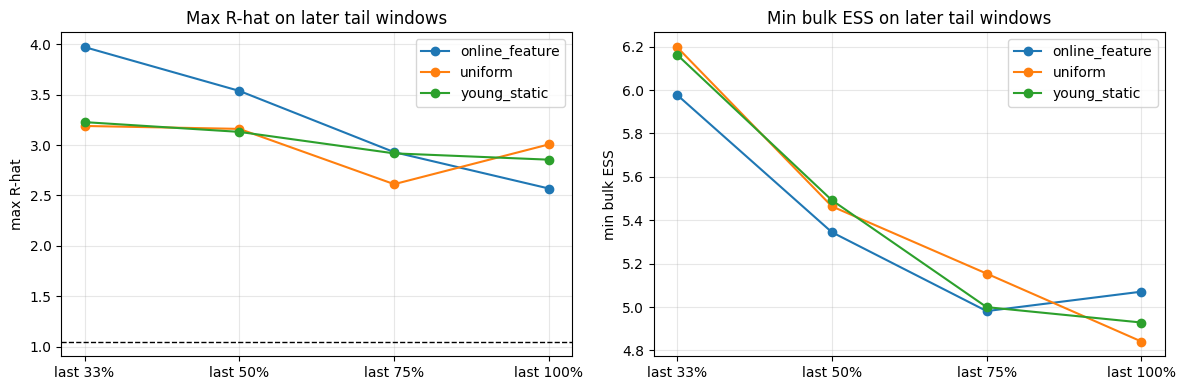

In [42]:
window_rows = []

tail_fracs = [1.00, 0.75, 0.50, 0.33]

for method_name, out in method_diagnostics.items():
    chain_dfs = out["chain_dfs"]
    min_len = min(len(df) for df in chain_dfs)
    print(f"{method_name}: min saved draws per chain = {min_len}")

    for frac in tail_fracs:
        keep = max(8, int(np.floor(min_len * frac)))
        tail_chain_dfs = [df.iloc[-keep:].reset_index(drop=True) for df in chain_dfs]

        _, diag_tail = compute_mcmc_diagnostics(
            chain_dfs=tail_chain_dfs,
            runtimes=None,
            monitored_vars=[v for v in MONITORED_VARS if v in tail_chain_dfs[0].columns],
        )

        window_rows.append({
            "method": method_name,
            "tail_fraction": frac,
            "n_draws_per_chain": keep,
            "max_rhat": float(diag_tail["rhat"].max()),
            "median_rhat": float(diag_tail["rhat"].median()),
            "min_ess_bulk": float(diag_tail["ess_bulk"].min()),
            "median_ess_bulk": float(diag_tail["ess_bulk"].median()),
        })

window_diag_df = pd.DataFrame(window_rows)
display(window_diag_df.sort_values(["method", "tail_fraction"], ascending=[True, False]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for method_name, g in window_diag_df.groupby("method"):
    g = g.sort_values("tail_fraction")
    x = [f"last {int(100*f)}%" for f in g["tail_fraction"]]

    axes[0].plot(x, g["max_rhat"], marker="o", label=method_name)
    axes[1].plot(x, g["min_ess_bulk"], marker="o", label=method_name)

axes[0].axhline(1.05, color="black", ls="--", lw=1)
axes[0].set_title("Max R-hat on later tail windows")
axes[0].set_ylabel("max R-hat")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_title("Min bulk ESS on later tail windows")
axes[1].set_ylabel("min bulk ESS")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


## Visual comparison

These plots are the quick read for mixing and occupancy before we compare the estimates directly to the known truth.


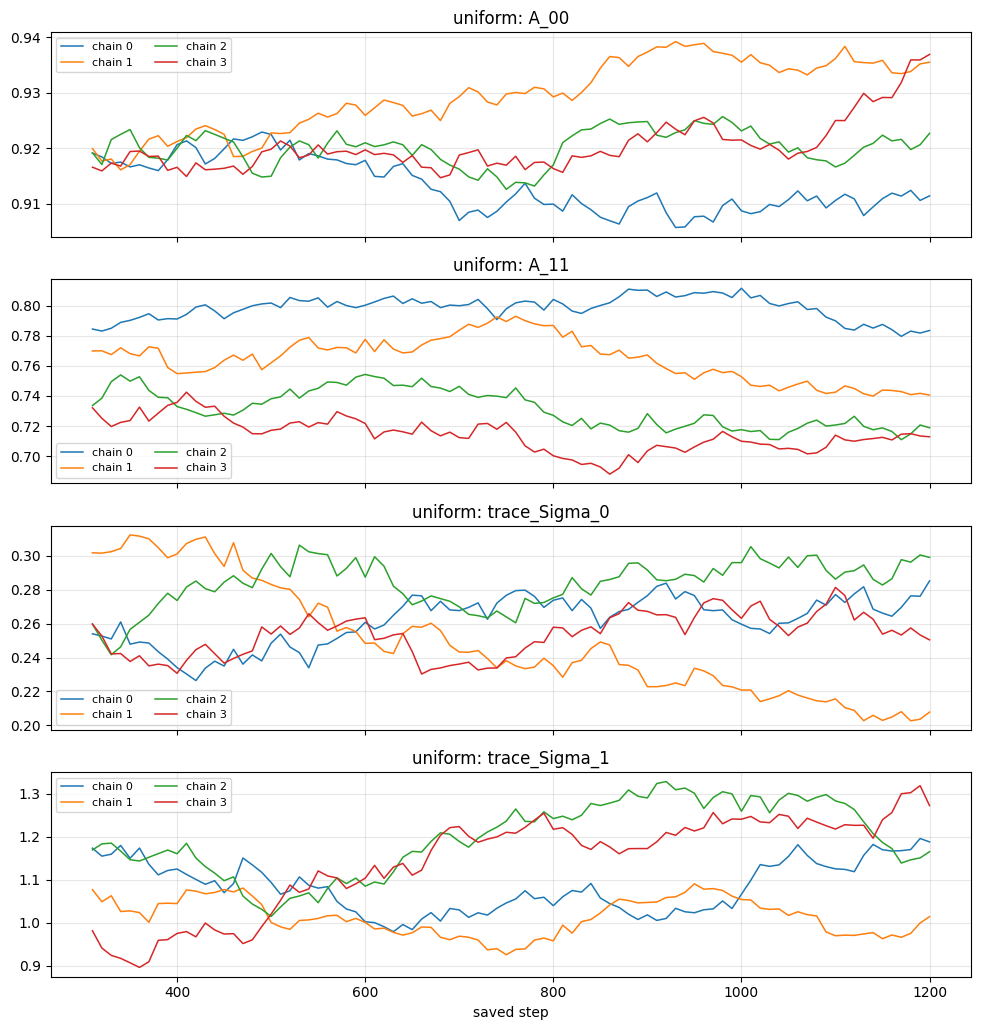

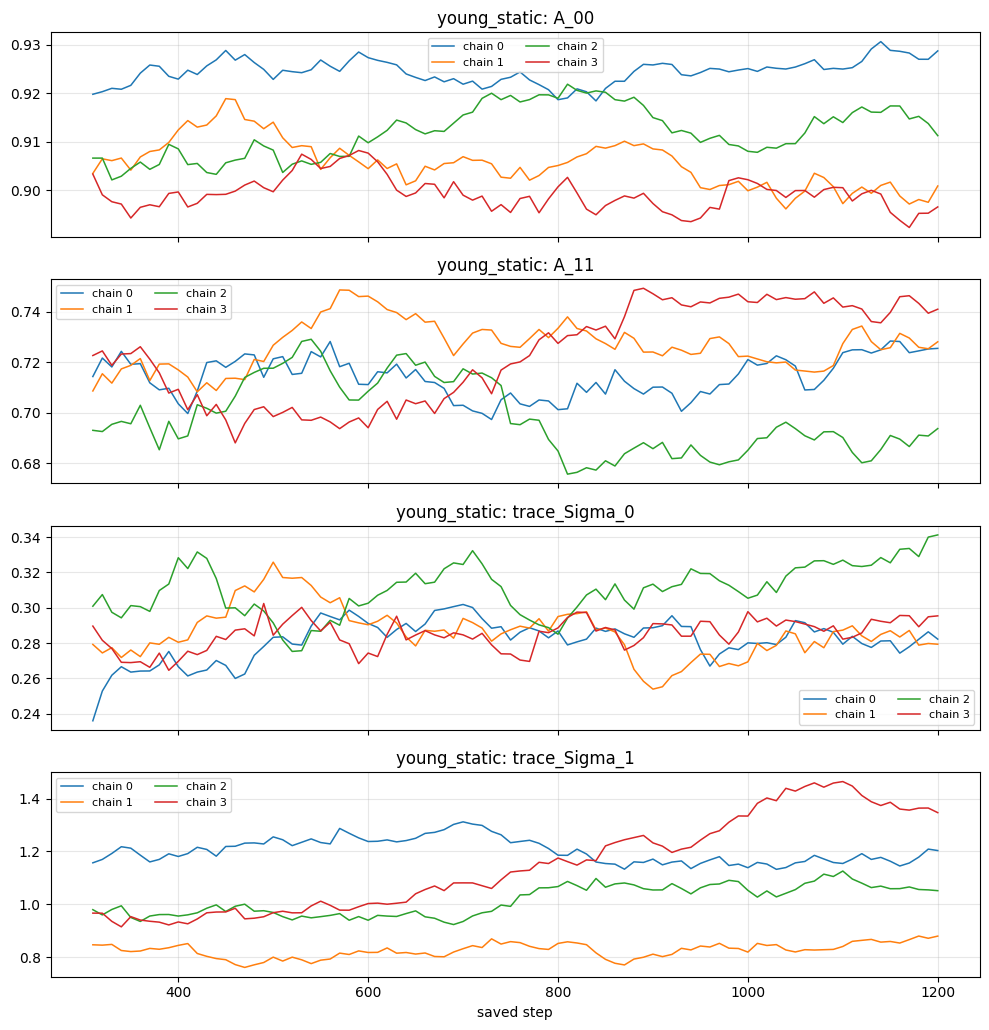

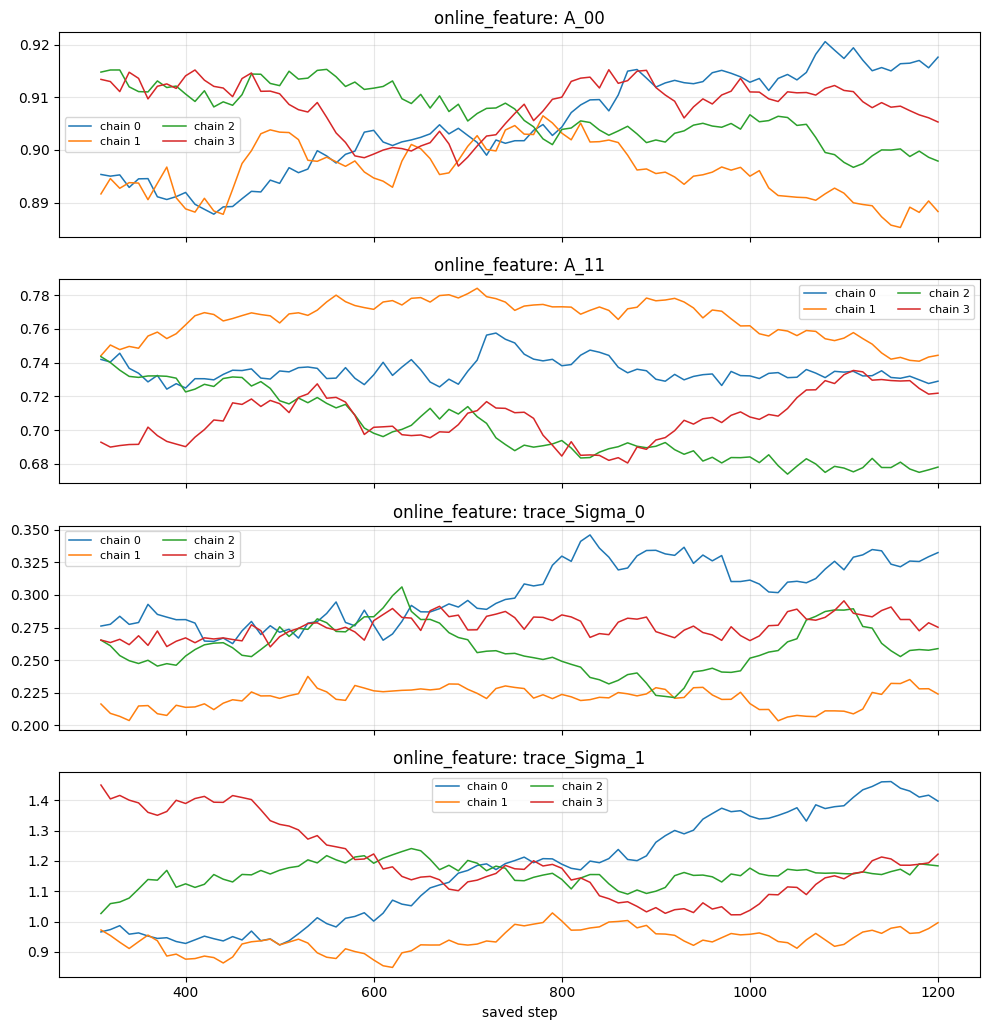

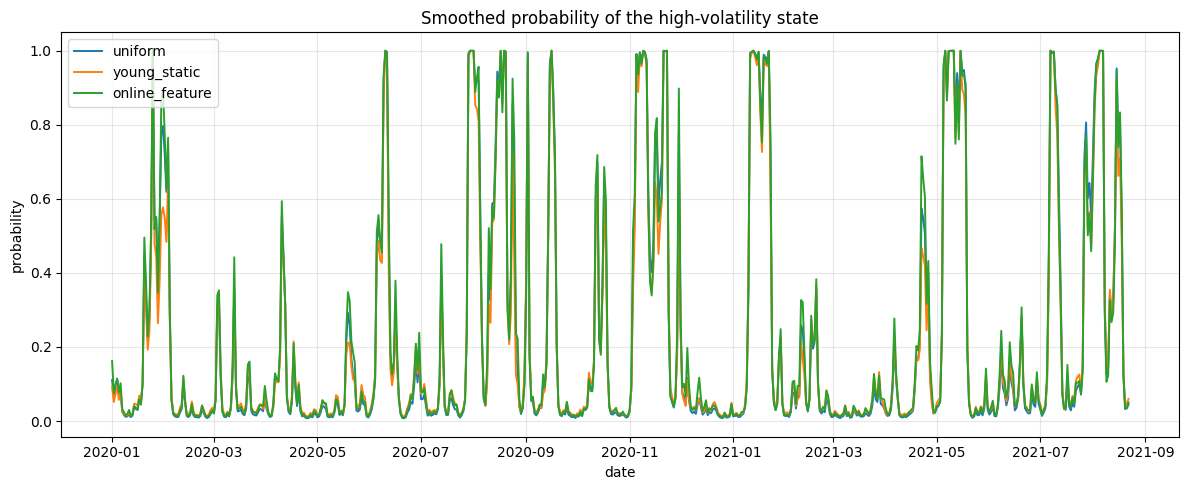

,method,state,ml_share,avg_smoothed_prob
0,uniform,state_0,0.806667,0.775783
1,uniform,state_1,0.193333,0.224217
2,young_static,state_0,0.833333,0.782062
3,young_static,state_1,0.166667,0.217938
4,online_feature,state_0,0.805000,0.767388
5,online_feature,state_1,0.195000,0.232612


In [36]:
TRACE_VARS = ['A_00', 'A_11', 'trace_Sigma_0', 'trace_Sigma_1']
for method_name, out in method_diagnostics.items():
    fig, axes = plt.subplots(len(TRACE_VARS), 1, figsize=(10, 2.6 * len(TRACE_VARS)), sharex=True)
    if len(TRACE_VARS) == 1:
        axes = [axes]
    for ax, var in zip(axes, TRACE_VARS):
        for chain_id, df in enumerate(out['chain_dfs']):
            ax.plot(df['step'], df[var], lw=1.1, label=f'chain {chain_id}')
        ax.set_title(f'{method_name}: {var}')
        ax.grid(alpha=0.3)
        ax.legend(ncol=2, fontsize=8)
    axes[-1].set_xlabel('saved step')
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(12, 5))
for method_name, sm_df in smoothed_by_method.items():
    plt.plot(pd.to_datetime(sm_df['date']), sm_df['state_1_prob'], lw=1.4, label=method_name)
plt.title('Smoothed probability of the high-volatility state')
plt.xlabel('date')
plt.ylabel('probability')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

occupancy_rows = []
for method_name, sm_df in smoothed_by_method.items():
    ml_state = sm_df['ml_state'].to_numpy()
    ml_share = np.bincount(ml_state, minlength=K) / len(ml_state)
    avg_prob = sm_df[[f'state_{k}_prob' for k in range(K)]].mean(axis=0).to_numpy()
    for k in range(K):
        occupancy_rows.append({'method': method_name, 'state': f'state_{k}', 'ml_share': float(ml_share[k]), 'avg_smoothed_prob': float(avg_prob[k])})
occupancy_df = pd.DataFrame(occupancy_rows)
display(occupancy_df)



uniform: min saved draws per chain = 90
young_static: min saved draws per chain = 90
online_feature: min saved draws per chain = 90


,method,tail_fraction,n_draws_per_chain,max_rhat,median_rhat,min_ess_bulk,median_ess_bulk
8,online_feature,1.00,90,2.568470,2.018211,5.070961,5.795071
9,online_feature,0.75,67,2.929665,2.173781,4.981408,5.606381
10,online_feature,0.50,45,3.537461,2.612479,5.344943,5.734339
11,online_feature,0.33,29,3.972564,2.986941,5.978003,6.313990
0,uniform,1.00,90,3.006941,1.871558,4.841042,6.121561
1,uniform,0.75,67,2.611829,2.434324,5.154128,5.330052
2,uniform,0.50,45,3.160518,2.155278,5.463998,6.196949
3,uniform,0.33,29,3.189571,2.612860,6.197951,6.496468
4,young_static,1.00,90,2.854988,2.166185,4.928711,5.591899
5,young_static,0.75,67,2.917574,2.114560,4.999575,5.691674


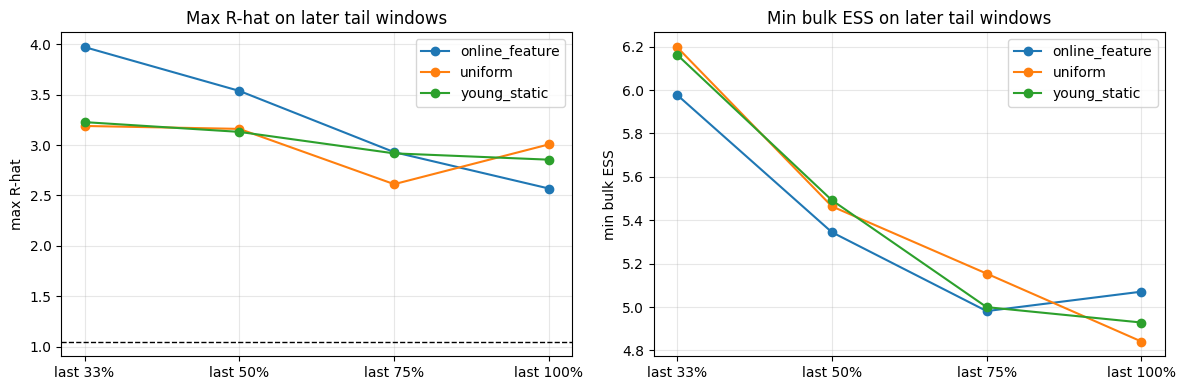

In [37]:
window_rows = []

tail_fracs = [1.00, 0.75, 0.50, 0.33]

for method_name, out in method_diagnostics.items():
    chain_dfs = out["chain_dfs"]

    min_len = min(len(df) for df in chain_dfs)
    print(f"{method_name}: min saved draws per chain = {min_len}")

    for frac in tail_fracs:
        keep = max(8, int(np.floor(min_len * frac)))
        tail_chain_dfs = [df.iloc[-keep:].reset_index(drop=True) for df in chain_dfs]

        _, diag_tail = compute_mcmc_diagnostics(
            chain_dfs=tail_chain_dfs,
            runtimes=None,
            monitored_vars=[v for v in MONITORED_VARS if v in tail_chain_dfs[0].columns],
        )

        window_rows.append({
            "method": method_name,
            "tail_fraction": frac,
            "n_draws_per_chain": keep,
            "max_rhat": float(diag_tail["rhat"].max()),
            "median_rhat": float(diag_tail["rhat"].median()),
            "min_ess_bulk": float(diag_tail["ess_bulk"].min()),
            "median_ess_bulk": float(diag_tail["ess_bulk"].median()),
        })

window_diag_df = pd.DataFrame(window_rows)
display(window_diag_df.sort_values(["method", "tail_fraction"], ascending=[True, False]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for method_name, g in window_diag_df.groupby("method"):
    g = g.sort_values("tail_fraction")
    label_x = [f"last {int(100*x)}%" for x in g["tail_fraction"]]

    axes[0].plot(label_x, g["max_rhat"], marker="o", label=method_name)
    axes[1].plot(label_x, g["min_ess_bulk"], marker="o", label=method_name)

axes[0].axhline(1.05, color="black", ls="--", lw=1)
axes[0].set_title("Max R-hat on later tail windows")
axes[0].set_ylabel("max R-hat")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_title("Min bulk ESS on later tail windows")
axes[1].set_ylabel("min bulk ESS")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()




## Truth recovery against the known simulation

Because this benchmark is simulated from known parameters and latent states, we can compare each method directly to truth. The two main questions are whether the posterior means recover the true parameters and whether the smoothed state probabilities recover the true hidden-state path.


In [39]:

true_params = params_from_transformed(TRUE_A, TRUE_MU, TRUE_SIGMA)
_, gamma_oracle = smooth_states(true_params, R)
gamma_oracle_np = np.asarray(gamma_oracle)

A_map, pi_map, mu_map, L_map, Sigma_map = unpack_params(params_map)
gamma_map_np = np.asarray(gamma_map)


def state_metrics(gamma_np, z_true):
    ml_state = gamma_np.argmax(axis=1)
    truth_state1 = (z_true == 1).astype(float)
    prob_true_state = gamma_np[np.arange(len(z_true)), z_true]
    if np.std(gamma_np[:, 1]) > 0 and np.std(truth_state1) > 0:
        corr = float(np.corrcoef(gamma_np[:, 1], truth_state1)[0, 1])
    else:
        corr = np.nan
    return {
        'ml_state_accuracy': float(np.mean(ml_state == z_true)),
        'avg_prob_on_true_state': float(np.mean(prob_true_state)),
        'brier_state1_prob': float(np.mean((gamma_np[:, 1] - truth_state1) ** 2)),
        'corr_state1_prob_with_truth': corr,
    }


def add_recovery_row(rows, method_name, A_hat, mu_hat, Sigma_hat, gamma_np):
    metrics = state_metrics(gamma_np, z_true)
    rows.append({
        'method': method_name,
        'A_rmse': float(np.sqrt(np.mean((np.asarray(A_hat) - TRUE_A) ** 2))),
        'mu_rmse': float(np.sqrt(np.mean((np.asarray(mu_hat) - TRUE_MU) ** 2))),
        'Sigma_rmse': float(np.sqrt(np.mean((np.asarray(Sigma_hat) - TRUE_SIGMA) ** 2))),
        'trace_sigma_0_error': float(np.trace(np.asarray(Sigma_hat)[0]) - np.trace(TRUE_SIGMA[0])),
        'trace_sigma_1_error': float(np.trace(np.asarray(Sigma_hat)[1]) - np.trace(TRUE_SIGMA[1])),
        **metrics,
    })


recovery_rows = []
add_recovery_row(recovery_rows, 'oracle_true_params', TRUE_A, TRUE_MU, TRUE_SIGMA, gamma_oracle_np)
add_recovery_row(recovery_rows, 'exact_map', np.asarray(A_map), np.asarray(mu_map), np.asarray(Sigma_map), gamma_map_np)

for method_name, summary in method_summary_tables.items():
    A_hat = summary['A']
    mu_hat = summary['mu']
    Sigma_hat = summary['Sigma']
    sm_df = smoothed_by_method[method_name]
    gamma_np = sm_df[[f'state_{k}_prob' for k in range(K)]].to_numpy(dtype=float)
    add_recovery_row(recovery_rows, method_name, A_hat, mu_hat, Sigma_hat, gamma_np)

recovery_df = pd.DataFrame(recovery_rows)
display(recovery_df.sort_values('ml_state_accuracy', ascending=False))



KeyError: 'A'

## Truth versus estimated state probabilities

This is the most interpretable benchmark plot in the simulation notebook: the true high-volatility state path is shown alongside the posterior-mean state-1 probability from the MAP fit and each stochastic-gradient method.


In [ ]:

fig, axes = plt.subplots(5, 1, figsize=(13, 12), sharex=True)

axes[0].step(dates, (z_true == 1).astype(float), where='post', color='black', lw=1.6)
axes[0].set_title('True latent state (state 1 indicator)')
axes[0].set_ylabel('truth')
axes[0].set_ylim(-0.05, 1.05)
axes[0].grid(alpha=0.25)

comparison_series = {
    'exact_map': gamma_map_np[:, 1],
    'uniform': smoothed_by_method['uniform']['state_1_prob'].to_numpy(),
    'young_static': smoothed_by_method['young_static']['state_1_prob'].to_numpy(),
    'online_feature': smoothed_by_method['online_feature']['state_1_prob'].to_numpy(),
}

for ax, (label, series) in zip(axes[1:], comparison_series.items()):
    ax.step(dates, (z_true == 1).astype(float), where='post', color='black', lw=1.0, alpha=0.6, label='true state 1')
    ax.plot(dates, series, lw=1.5, label=label)
    ax.set_title(f'{label}: posterior-mean probability of state 1')
    ax.set_ylabel('probability')
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.25)
    ax.legend(loc='upper right')

axes[-1].set_xlabel('date')
plt.tight_layout()
plt.show()

